# Data import

> **Reporting note:** The article is the official source for study definitions and findings. This notebook preserves the saved analysis sequence and outputs; no cell was rerun for the public release.


In [81]:
import pandas as pd
from IPython.display import display

base = r'analysis_data/'

# read latest data suffix in filename
def read_latest_data(file_prefix: str) -> pd.DataFrame:
    import os
    files = [f for f in os.listdir(base) if f.startswith(file_prefix)]
    latest_file = max(files, key=lambda f: os.path.getmtime(os.path.join(base, f)))
    return pd.read_csv(os.path.join(base, latest_file))

dem = read_latest_data('prolific_data_') # demographic data from prolific
tr = read_latest_data('task_responses_')
qr = read_latest_data('questionnaire_responses_')
convs = read_latest_data('chat_conversations_')
mgs = read_latest_data('chat_message_')
ga = read_latest_data('group_assignments_')
ets = read_latest_data('dashboard_events_')

In [82]:
mgs.participant_id.isna().sum()

np.int64(262)

# Utilities

In [19]:
import scipy.stats as stats
import numpy as np
def ci_mean(data, conf=0.95, nan_policy="omit"):
    x = np.asarray(data, dtype=float)
    if nan_policy == "omit":
        x = x[~np.isnan(x)]
    n = x.size
    if n < 2:
        raise ValueError("Need at least 2 not-NaN observations for to CI.")
    m = x.mean()
    se = stats.sem(x)  # uses ddof=1
    tcrit = stats.t.ppf((1 + conf) / 2, df=n - 1)
    h = tcrit * se
    return m, m - h, m + h

def bootstrap_ci_mean(data, conf=0.95, n_boot=10000, nan_policy="omit", random_state=None):
    """
    Percentile bootstrap CI for the mean.

    Returns: (mean, ci_low, ci_high)
    """
    x = np.asarray(data, dtype=float)
    if nan_policy == "omit":
        x = x[~np.isnan(x)]

    n = x.size
    if n < 2:
        raise ValueError("Need at least 2 not-NaN observations for to CI.")

    rng = np.random.default_rng(random_state)

    # Observed mean
    m = float(x.mean())

    # Bootstrap resamples (vectorized)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = x[idx].mean(axis=1)

    alpha = 1.0 - conf
    lo = float(np.quantile(boot_means, alpha / 2))
    hi = float(np.quantile(boot_means, 1 - alpha / 2))

    return m, lo, hi


# Example:
# m, lo, hi = bootstrap_ci_mean(data, conf=0.95, n_boot=20000, random_state=42)
# print(m, lo, hi)


# Descriptive Stats

In [20]:
ga.groupby('interface_cond').size()

interface_cond
chatbot      64
dashboard    70
dtype: int64

## Sample Demographics

### Prolific Dems

Age: count    134.000000
mean      39.447761
std       10.037199
min       24.000000
25%       33.000000
50%       37.500000
75%       45.000000
max       69.000000
Name: Age, dtype: float64
Age median: 37.5
Age IQR: 33.0 - 45.0
Sex: Sex
Male      103
Female     31
Name: count, dtype: int64
Sex percentages: Sex
Male      76.865672
Female    23.134328
Name: proportion, dtype: float64
Highest education level completed: Highest education level completed
Undergraduate degree (BA/BSc/other)     66
Graduate degree (MA/MSc/MPhil/other)    38
Technical/community college             17
High school diploma/A-levels             8
Secondary education (e.g. GED/GCSE)      4
Doctorate degree (PhD/other)             1
Name: count, dtype: int64
Highest education level completed percentages: Highest education level completed
Undergraduate degree (BA/BSc/other)     49.253731
Graduate degree (MA/MSc/MPhil/other)    28.358209
Technical/community college             12.686567
High school diploma/A-levels  

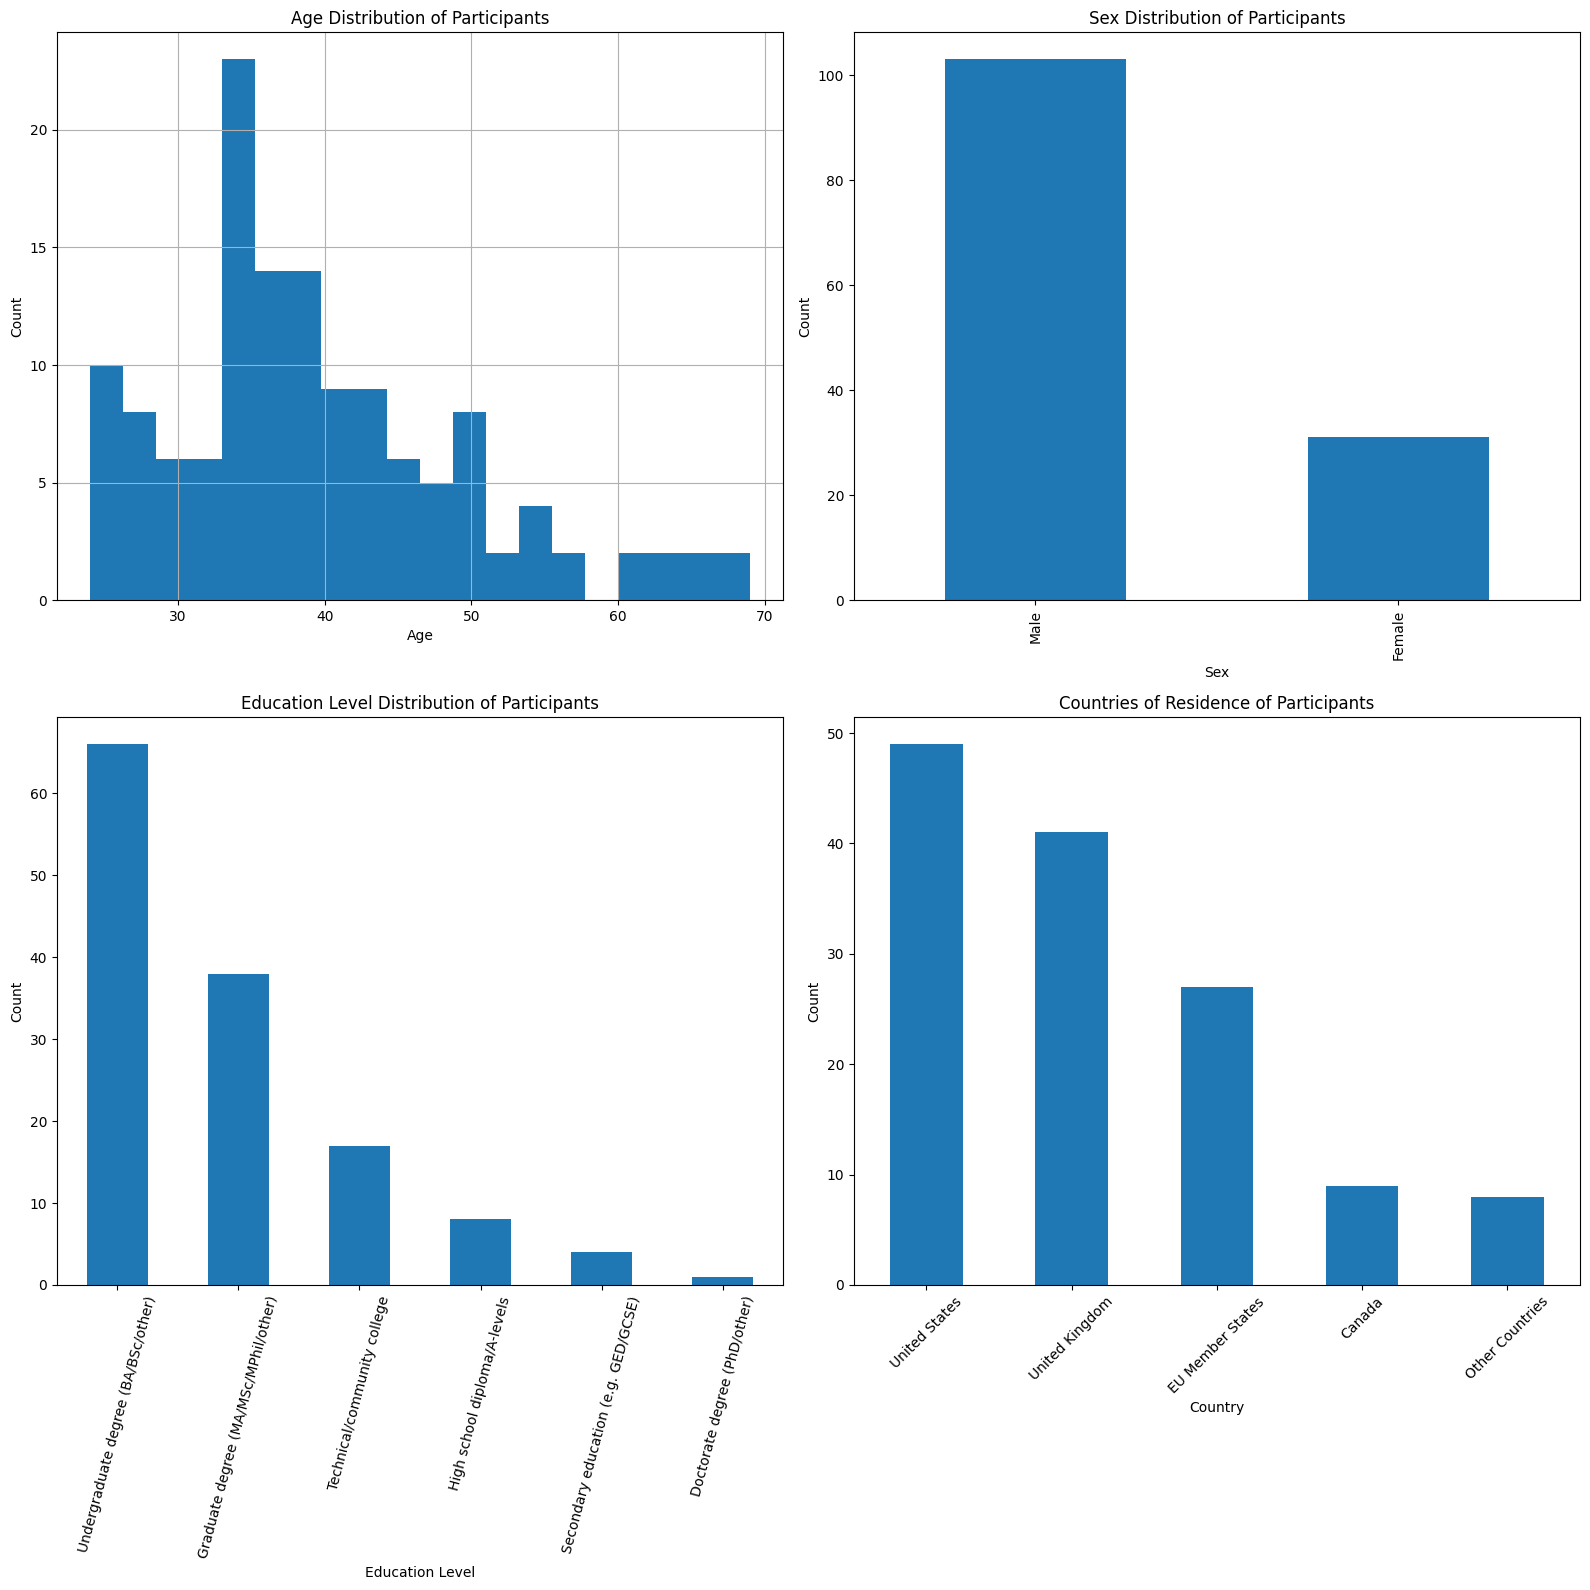

In [21]:
import matplotlib.pyplot as plt

# Put together eu member states , the UK, US, Canada, and other countries
eu_countries = ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 
                'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 
                'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']
dem['Country of residence'] = dem['Country of residence'].replace(eu_countries, 'EU Member States')

other_countries = dem[~dem['Country of residence'].isin(["EU Member States", "United Kingdom", "United States", "Canada"])]['Country of residence'].unique().tolist()

dem['Country of residence'] = dem['Country of residence'].replace(other_countries, 'Other Countries')


# age descriptive statistics
print("Age: " + str(dem['Age'].describe()))
# age median and IQR [Q3 - Q1]
print("Age median: " + str(dem['Age'].median()))
print("Age IQR: " + str(dem['Age'].quantile(0.25)) + " - " + str(dem['Age'].quantile(0.75)))

# sex and percentages
print("Sex: " + str(dem['Sex'].value_counts()))
print("Sex percentages: " + str(dem['Sex'].value_counts(normalize=True) * 100))
# education and percentages
print("Highest education level completed: " + str(dem['Highest education level completed'].value_counts()))
print("Highest education level completed percentages: " + str(dem['Highest education level completed'].value_counts(normalize=True) * 100))

# country of residence and percentages
print("Country of residence: " + str(dem['Country of residence'].value_counts()))
print("Country of residence percentages: " + str(dem['Country of residence'].value_counts(normalize=True) * 100))


fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Plot age distribution
dem['Age'].hist(bins=20, ax=axes[0, 0])
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Age Distribution of Participants')

# Plot sex distribution
dem['Sex'].value_counts().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_xlabel('Sex')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Sex Distribution of Participants')

# Plot education distribution
dem['Highest education level completed'].value_counts().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_xlabel('Education Level')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Education Level Distribution of Participants')
axes[1, 0].tick_params(axis='x', rotation=75)



# Plot country distribution
dem['Country of residence'].value_counts().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_xlabel('Country')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Countries of Residence of Participants')
axes[1, 1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

### Study Dems

In [22]:
prescreen = qr[qr['questionnaire_name'] == 'PrescreenStart'][['participant_id', 'item_key', 'value_text']].pivot(columns='item_key', values='value_text')
# split decision_responsibilities into list
def split_and_clean(s):
    if pd.isna(s):
        return []
    return [i.strip() for i in str(s).split('|') if i.strip()]

prescreen['decision_responsibilities'] = prescreen['decision_responsibilities'].apply(split_and_clean)

Industries: industry
Manufacturing                             88
Oil and Gas, Utilities, Mining            16
Computer and Electronics Manufacturing    11
Automotive                                 6
Engineering                                6
Other Manufacturing                        5
Pharmaceuticals / Bio-tech                 2
Name: count, dtype: int64
Industries percentages: industry
Manufacturing                             65.671642
Oil and Gas, Utilities, Mining            11.940299
Computer and Electronics Manufacturing     8.208955
Automotive                                 4.477612
Engineering                                4.477612
Other Manufacturing                        3.731343
Pharmaceuticals / Bio-tech                 1.492537
Name: proportion, dtype: float64
Industry Roles: industry_role
Middle Management    85
Upper Management     28
Junior Management    21
Name: count, dtype: int64
Industry Roles percentages: industry_role
Middle Management    63.432836
Upper M

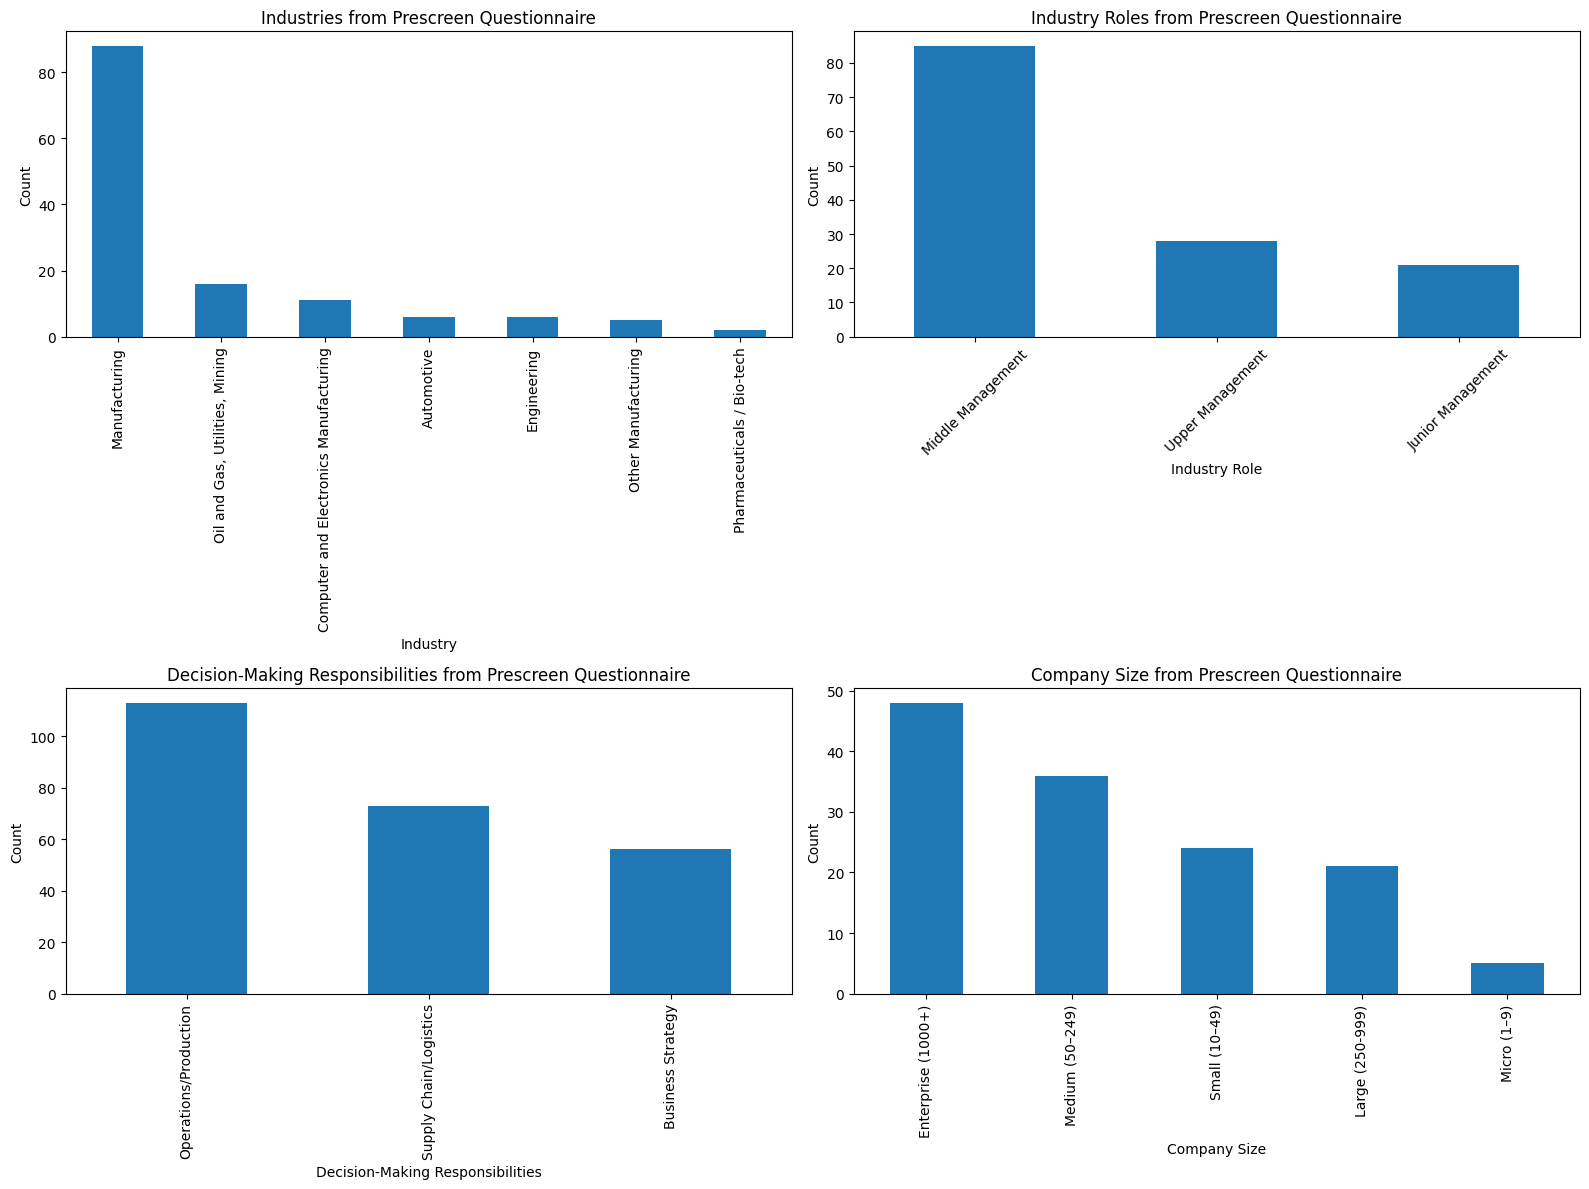

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# put together Oil \& gas / utilities / mining
prescreen['industry'] = prescreen['industry'].replace(['Oil and Gas', 'Utilities', 'Mining'], 'Oil and Gas, Utilities, Mining')

# industry and percentages
print("Industries: " + str(prescreen['industry'].value_counts()))
print("Industries percentages: " + str(prescreen['industry'].value_counts(normalize=True) * 100))
# industry role and percentages
print("Industry Roles: " + str(prescreen['industry_role'].value_counts()))
print("Industry Roles percentages: " + str(prescreen['industry_role'].value_counts(normalize=True) * 100))
# decision responsibilities and percentages
all_decision_responsibilities = prescreen.explode('decision_responsibilities')['decision_responsibilities']
# focus on operations/production, supply chain/logistics, or business strategy, the rest grouped as 'Other' and gets filtered out
all_decision_responsibilities = all_decision_responsibilities.replace(['Operations/production', 'Supply chain/logistics', 'Business strategy'], ['Operations/Production', 'Supply Chain/Logistics', 'Business Strategy'])
other_responsibilities = all_decision_responsibilities[~all_decision_responsibilities.isin(['Operations/Production', 'Supply Chain/Logistics', 'Business Strategy'])]
all_decision_responsibilities = all_decision_responsibilities[all_decision_responsibilities.isin(['Operations/Production', 'Supply Chain/Logistics', 'Business Strategy'])]
print("Decision-Making Responsibilities: " + str(all_decision_responsibilities.value_counts()))
print("Decision-Making Responsibilities percentages: " + str(all_decision_responsibilities.value_counts(normalize=True) * 100))
# compute number of participants that declare other_responsabilities
num_other_responsibilities = prescreen['decision_responsibilities'].apply(lambda x: any(item not in ['Operations/production', 'Supply chain/logistics', 'Business strategy'] for item in x)).sum()
print("Number of participants with 'Other' decision-making responsibilities: " + str(num_other_responsibilities))
# company size and percentages
print("Company Size: " + str(prescreen['company_size'].value_counts()))
print("Company Size percentages: " + str(prescreen['company_size'].value_counts(normalize=True) * 100)) 
                                                

prescreen['industry'].value_counts().plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_xlabel('Industry')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Industries from Prescreen Questionnaire')
axes[0, 0].tick_params(axis='x', rotation=90)

prescreen['industry_role'].value_counts().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_xlabel('Industry Role')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Industry Roles from Prescreen Questionnaire')
axes[0, 1].tick_params(axis='x', rotation=45)

all_decision_responsibilities.value_counts().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_xlabel('Decision-Making Responsibilities')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Decision-Making Responsibilities from Prescreen Questionnaire')
axes[1, 0].tick_params(axis='x', rotation=90)

prescreen['company_size'].value_counts().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_xlabel('Company Size')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Company Size from Prescreen Questionnaire')

plt.tight_layout()
plt.show()

**Capability values** 
0: No experience (need guidance for basics) 
1: Beginner (simple tasks with occasional help) 
2: Intermediate (independent on routine tasks) 
3: Advanced/Expert (optimize, integrate, troubleshoot) 

**Use values** 
0: Never 
1: Rarely (≤ monthly) 
2: Often (weekly) 
3: Very often (daily)



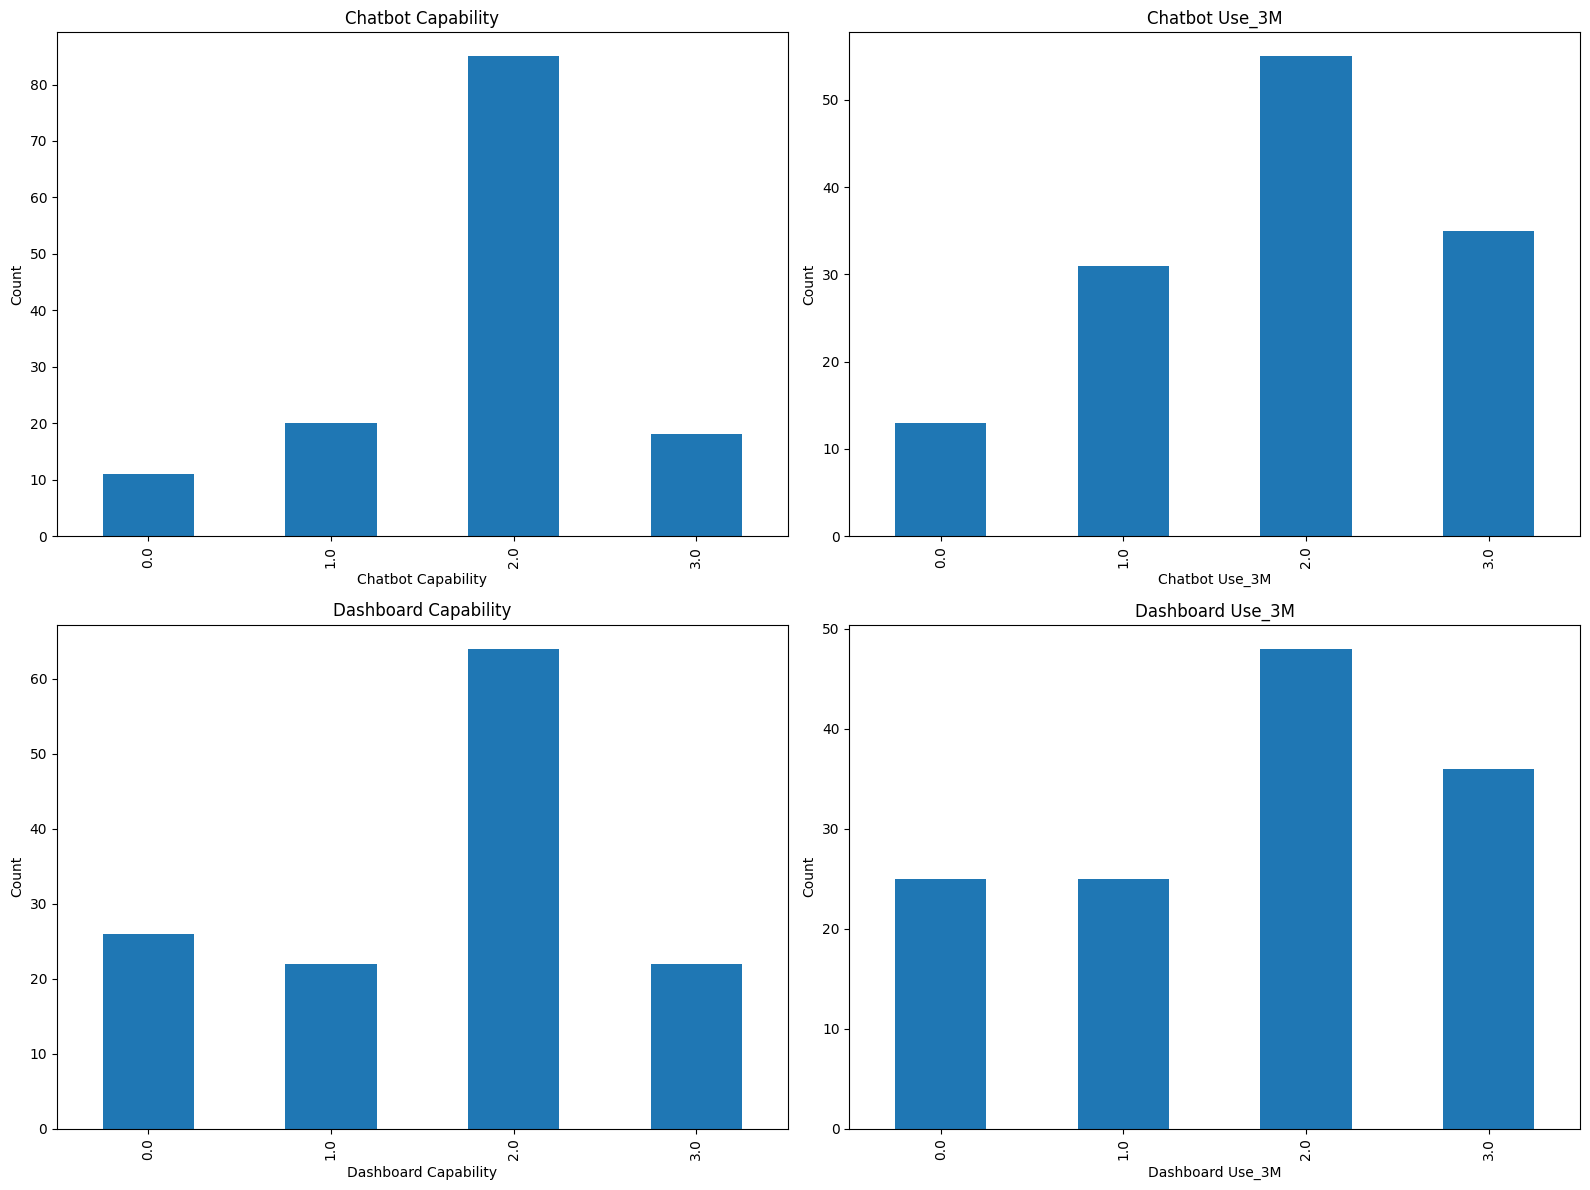

In [24]:
fam = qr[qr['questionnaire_name'] == 'TechFam'][['participant_id', 'item_key', 'value_numeric']].pivot(columns='item_key', values='value_numeric')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cols = ['chatbot.capability', 'chatbot.use_3m', 'dashboard.capability', 'dashboard.use_3m']
titles = [col.replace('.', ' ').title() for col in cols]

for i, (col, title) in enumerate(zip(cols, titles)):
    row = i // 2
    col_idx = i % 2
    fam[col].value_counts().sort_index().plot(kind='bar', ax=axes[row, col_idx])
    axes[row, col_idx].set_xlabel(title)
    axes[row, col_idx].set_ylabel('Count')
    axes[row, col_idx].set_title(title)

plt.tight_layout()
plt.show()

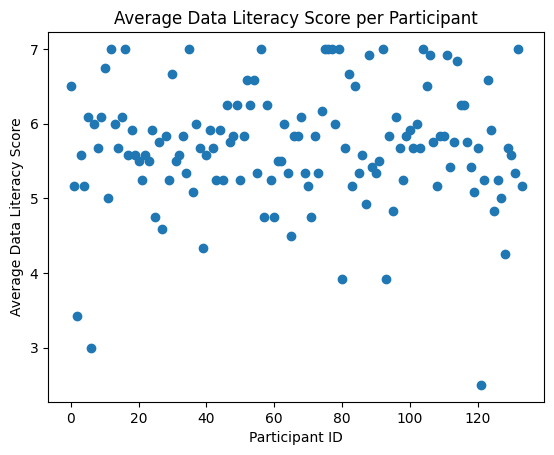

In [25]:
dl = qr[qr['questionnaire_name'] == 'BDLI'][['participant_id', 'item_key', 'value_numeric']]

# first compute the mean per participant
dl = dl.groupby(['participant_id'])['value_numeric'].mean().reset_index()
# scatter plot data literacy 
import matplotlib.pyplot as plt
plt.scatter(range(len(dl)), dl['value_numeric'])
plt.xlabel('Participant ID')
plt.ylabel('Average Data Literacy Score')
plt.title('Average Data Literacy Score per Participant')
plt.show()

### No Dash Experience

Twenty-six participants reported no prior dashboard use, split evenly between the two interface conditions. This was considered as a possible sensitivity check, subject to the smaller resulting sample.


In [26]:
pr_no_dash = qr[(qr['questionnaire_name'] == 'TechFam') & (qr['item_key'] == 'dashboard.capability') & (qr['value_numeric'] == 0) ].participant_id.to_list()
ga[ga['participant_id'].isin(pr_no_dash)].interface_cond.value_counts()


interface_cond
chatbot      13
dashboard    13
Name: count, dtype: int64

## Overtime and skipped tasks


In [27]:
print(tr.status.value_counts())
display(tr[tr['status'] == 'skipped'])

# Find participants who have multiple overtime entries and show them
overtime_counts = tr[tr['status'] == 'overtime']['participant_id'].value_counts()
multiple_overtime_participants = overtime_counts[overtime_counts > 1].index.tolist()
if multiple_overtime_participants:
    print("Participants with multiple overtime entries:")
    display(tr[tr['participant_id'].isin(multiple_overtime_participants)].sort_values(by=['participant_id']))

status
completed    366
overtime      33
skipped        3
Name: count, dtype: int64


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

Participants with multiple overtime entries:


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

## Main outcome measures


### Decision accuracy by task (reference solutions: Supplementary Material S1)


In [51]:
print("Accuracy Scores per task:")
# group task responses by task_code and show mean accuracy
grouped_tr = tr.groupby(['participant_id', 'task_code'])['accuracy_score'].mean().reset_index()
display(grouped_tr.groupby('task_code')['accuracy_score'].mean().reset_index())

print("Accuracy Scores per interface-task with CI:")
# show confidence intervals
grouped_tr_ci = grouped_tr.merge(ga, on='participant_id').groupby(['interface_cond', 'task_code'])['accuracy_score'].apply(ci_mean).reset_index()
grouped_tr_ci[['mean', 'ci_lower', 'ci_upper']] = pd.DataFrame(grouped_tr_ci['accuracy_score'].tolist(), index=grouped_tr_ci.index)
grouped_tr_ci = grouped_tr_ci.drop(columns=['accuracy_score'])
display(grouped_tr_ci)

Accuracy Scores per task:


,task_code,accuracy_score
0,T1,0.893787
1,T2,0.845491
2,T3,0.487505


Accuracy Scores per interface-task with CI:


,interface_cond,task_code,mean,ci_lower,ci_upper
0,chatbot,T1,0.933458,0.893850,0.973065
1,chatbot,T2,0.865597,0.817252,0.913942
2,chatbot,T3,0.470839,0.426211,0.515467
3,dashboard,T1,0.856991,0.809601,0.904381
4,dashboard,T2,0.827108,0.771368,0.882847
5,dashboard,T3,0.502266,0.455884,0.548648


### Raw NASA-TLX by task


In [53]:
print("NASA-TLX Scores per task:")
# group NASA-TLX scores by task_code and show mean
nasa = qr[qr['questionnaire_name'] == 'NASA-TLX'].groupby(['participant_id', 'task_code'])['value_numeric'].mean().reset_index()
display(nasa.groupby('task_code')['value_numeric'].mean().reset_index())

print("NASA-TLX Scores per interface-task with CI:")
# show confidence intervals with bootstrap_ci_mean
nasa_ci = nasa.merge(ga, on='participant_id').groupby(['interface_cond', 'task_code'])['value_numeric'].apply(bootstrap_ci_mean).reset_index()
nasa_ci[['mean', 'ci_lower', 'ci_upper']] = pd.DataFrame(nasa_ci['value_numeric'].tolist(), index=nasa_ci.index)
nasa_ci = nasa_ci.drop(columns=['value_numeric'])
display(nasa_ci)



NASA-TLX Scores per task:


,task_code,value_numeric
0,T1,24.185323
1,T2,28.731343
2,T3,45.839552


NASA-TLX Scores per interface-task with CI:


,interface_cond,task_code,mean,ci_lower,ci_upper
0,chatbot,T1,13.723958,10.364583,17.226562
1,chatbot,T2,22.721354,18.359375,27.239583
2,chatbot,T3,39.895833,34.348958,45.390951
3,dashboard,T1,33.750000,28.571131,39.155060
4,dashboard,T2,34.226190,30.226190,38.273810
5,dashboard,T3,51.273810,47.345238,55.083333


### Completion time by task


In [50]:
print("Completion time per task:")
# group task responses by task_code and show mean completion time
grouped_tr = tr.groupby(['participant_id', 'task_code'])['duration_ms'].mean().reset_index()
display(grouped_tr.groupby('task_code')['duration_ms'].mean().reset_index())

print("Completion time per interface-task with CI:")
# show confidence intervals
time_ci = grouped_tr.merge(ga, on='participant_id').groupby(['interface_cond', 'task_code'])['duration_ms'].apply(ci_mean).reset_index()
time_ci[['mean', 'ci_lower', 'ci_upper']] = pd.DataFrame(time_ci['duration_ms'].tolist(), index=time_ci.index)
time_ci = time_ci.drop(columns=['duration_ms'])
display(time_ci)

Completion time per task:


,task_code,duration_ms
0,T1,100501.723881
1,T2,193930.343284
2,T3,358508.888060


Completion time per interface-task with CI:


,interface_cond,task_code,mean,ci_lower,ci_upper
0,chatbot,T1,81166.125000,70802.494405,91529.755595
1,chatbot,T2,208533.281250,185358.357070,231708.205430
2,chatbot,T3,379966.750000,334098.721133,425834.778867
3,dashboard,T1,118179.985714,106242.886043,130117.085386
4,dashboard,T2,180579.085714,161552.605455,199605.565974
5,dashboard,T3,338890.271429,301950.768939,375829.773918


### Intended reliance by task


In [30]:
print("Reliance item1 Scores per task:")
rel1 = qr[qr['item_key'] == 'r1'].groupby(['participant_id', 'task_code'])['value_numeric'].first().reset_index()
display(rel1.groupby('task_code')['value_numeric'].mean().reset_index())

print("Reliance item1 Scores per interface-task with CI:")
# show confidence intervals
rel1_ci = rel1.merge(ga, on='participant_id').groupby(['interface_cond', 'task_code'])['value_numeric'].apply(ci_mean).reset_index()
rel1_ci[['mean', 'ci_lower', 'ci_upper']] = pd.DataFrame(rel1_ci['value_numeric'].tolist(), index=rel1_ci.index)
rel1_ci = rel1_ci.drop(columns=['value_numeric'])
display(rel1_ci)

#### RELIANCE ITEM 2
print("Reliance item2 Scores per task:")
rel2 = qr[qr['item_key'] == 'r2'].groupby(['participant_id', 'task_code'])['value_numeric'].first().reset_index()
display(rel2.groupby('task_code')['value_numeric'].mean().reset_index())

print("Reliance item2 Scores per interface-task with CI:")
# show confidence intervals
rel2_ci = rel2.merge(ga, on='participant_id').groupby(['interface_cond', 'task_code'])['value_numeric'].apply(ci_mean).reset_index()
rel2_ci[['mean', 'ci_lower', 'ci_upper']] = pd.DataFrame(rel2_ci['value_numeric'].tolist(), index=rel2_ci.index)
rel2_ci = rel2_ci.drop(columns=['value_numeric'])
display(rel2_ci)

#####  RELIANCE ITEM 3
print("Reliance item3 Scores per task:")
rel3 = qr[qr['item_key'] == 'r3'].groupby(['participant_id', 'task_code'])['value_numeric'].first().reset_index()
display(rel3.groupby('task_code')['value_numeric'].mean().reset_index())

print("Reliance item3 Scores per interface-task with CI:")
# show confidence intervals
rel3_ci = rel3.merge(ga, on='participant_id').groupby(['interface_cond', 'task_code'])['value_numeric'].apply(ci_mean).reset_index()
rel3_ci[['mean', 'ci_lower', 'ci_upper']] = pd.DataFrame(rel3_ci['value_numeric'].tolist(), index=rel3_ci.index)
rel3_ci = rel3_ci.drop(columns=['value_numeric'])
display(rel3_ci)

Reliance item1 Scores per task:


,task_code,value_numeric
0,T1,4.873134
1,T2,3.716418
2,T3,2.492537


Reliance item1 Scores per interface-task with CI:


,interface_cond,task_code,mean,ci_lower,ci_upper
0,chatbot,T1,4.843750,4.300079,5.387421
1,chatbot,T2,3.296875,2.756015,3.837735
2,chatbot,T3,2.546875,2.069741,3.024009
3,dashboard,T1,4.900000,4.391103,5.408897
4,dashboard,T2,4.100000,3.614300,4.585700
5,dashboard,T3,2.442857,2.050037,2.835677


Reliance item2 Scores per task:


...

,interface_cond,task_code,mean,ci_lower,ci_upper
0,chatbot,T1,2.515625,2.079569,2.951681
1,chatbot,T2,3.859375,3.340597,4.378153
2,chatbot,T3,5.015625,4.533201,5.498049
3,dashboard,T1,2.928571,2.458087,3.399056
4,dashboard,T2,4.114286,3.672298,4.556273
5,dashboard,T3,4.885714,4.432679,5.338749


Reliance item3 Scores per task:


,task_code,value_numeric
0,T1,3.865672
1,T2,4.723881
2,T3,5.529851


Reliance item3 Scores per interface-task with CI:


,interface_cond,task_code,mean,ci_lower,ci_upper
0,chatbot,T1,4.203125,3.687579,4.718671
1,chatbot,T2,5.171875,4.730037,5.613713
2,chatbot,T3,5.765625,5.355917,6.175333
3,dashboard,T1,3.557143,3.068929,4.045357
4,dashboard,T2,4.314286,3.854033,4.774538
5,dashboard,T3,5.314286,4.921661,5.706911


# Supplementary Material S4: copy–paste use checks (Tables S6–S7)

This supplementary analysis compares the 29 participants who copied and pasted chatbot output with the 35 who did not. Conversation-level records remain private.


In [83]:
import re
from difflib import SequenceMatcher

task_texts = {
    "T1": "On which day in May did the factory consume the most?",
    "T2": (
        "From September to October, your factory has noticed excessive energy waste from machines sitting idle unnecessarily for too long. "
        "Management is considering installing an automatic power-down feature on one cutting machine to reduce energy costs. "
        "During a recent team meeting, it was decided that we should compare how long different machines sit idle and how much energy they draw while idle. "
        "Based on these observations, on which cutting machine would this feature have the greatest impact? "
        "To give the process crew some room for manoeuvre when planning operations, please also indicate your second-best choice."
    ),
    "T3": (
        "Over the next 3 working days, we can deploy three specialist crews for one half-day each. "
        "Using data since the start of October, consider the period as a whole and pick three different machines, one for each crew to work on: "
        "- Maintenance crew: choose the machine where reducing stops and downtime would most improve overall output and stability. "
        "Check: Availability, Alarm time and number of Alarms, Idle time, Offline time, Utilization rate. "
        "- Process optimization crew: choose the machine where improving efficiency and flow would produce the biggest gain. "
        "Check: Performance, Average cycle time, Good cycles, Utilization rate, Consumption while working and Cost. "
        "- Quality crew: choose the machine where improving first-pass yield would save the most good parts. "
        "Check: Quality, Bad cycles, Average cycle cost, Good cycles. "
        "Assume safety is currently under control and comparable across machines. "
        "Constraint: to avoid disrupting operations and over-concentrating work on a single line, you must not select more than one machine from the same family "
        "(e.g., you can't pick two Medium Cutting machines, or two Assembly machines)."
    ),
}

def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    # Remove LaTeX/markdown markers while keeping content.
    text = re.sub(r"\\textbf\{([^}]*)\}", r"\1", text)
    text = text.replace("\\begin{itemize}", " ").replace("\\end{itemize}", " ").replace("\\item", " ")
    # Remove punctuation/symbols and collapse whitespace.
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def exact_match_info(message_norm, task_norm):
    if not message_norm or not task_norm:
        return False, None
    if message_norm == task_norm:
        return True, "full_equal"
    if task_norm in message_norm:
        return True, "contains_full_task"
    if len(message_norm) >= 30 and message_norm in task_norm:
        return True, "task_fragment"
    return False, None

convs_scope = convs[["conversation_id", "participant_id", "task_code"]].drop_duplicates()

messages_merged = mgs.merge(
    convs_scope.rename(
        columns={
            "participant_id": "participant_id_conv",
            "task_code": "task_code_conv",
        }
    ),
    on="conversation_id",
    how="left",
    indicator=True,
)

messages_scoped = messages_merged[messages_merged["_merge"] == "both"].copy()
messages_scoped["participant_id"] = messages_scoped["participant_id_conv"].combine_first(messages_scoped["participant_id"])
messages_scoped["task_code"] = messages_scoped["task_code_conv"].combine_first(messages_scoped["task_code"])

user_messages = messages_scoped[messages_scoped["role"] == "user"].copy()
user_messages["task_text"] = user_messages["task_code"].map(task_texts)

user_messages["message_norm"] = user_messages["content"].apply(normalize_text)
user_messages["task_norm"] = user_messages["task_text"].apply(normalize_text)

exact_info = user_messages.apply(
    lambda row: exact_match_info(row["message_norm"], row["task_norm"]),
    axis=1,
)
user_messages["exact_match"] = exact_info.apply(lambda x: x[0])
user_messages["exact_match_type"] = exact_info.apply(lambda x: x[1])

user_messages["similarity_ratio"] = user_messages.apply(
    lambda row: SequenceMatcher(None, row["message_norm"], row["task_norm"]).ratio()
    if row["message_norm"] and row["task_norm"]
    else 0.0,
    axis=1,
)

user_messages["near_match"] = (
    ~user_messages["exact_match"]
    & (user_messages["message_norm"].str.len() >= 60)
    & (user_messages["similarity_ratio"] >= 0.80)
)

user_messages["copy_paste_class"] = "none"
user_messages.loc[user_messages["near_match"], "copy_paste_class"] = "near"
user_messages.loc[user_messages["exact_match"], "copy_paste_class"] = "exact"

copy_paste_results = user_messages[
    [
        "conversation_id",
        "participant_id",
        "task_code",
        "ts",
        "role",
        "content",
        "message_norm",
        "task_norm",
        "exact_match",
        "exact_match_type",
        "similarity_ratio",
        "near_match",
        "copy_paste_class",
    ]
].copy()

copy_paste_results["ts"] = pd.to_datetime(copy_paste_results["ts"], errors="coerce")
copy_paste_results = copy_paste_results.sort_values(["participant_id", "task_code", "ts"])

copy_paste_results["match_type"] = "none"
copy_paste_results.loc[copy_paste_results["copy_paste_class"] == "near", "match_type"] = "near_similarity"
copy_paste_results.loc[copy_paste_results["copy_paste_class"] == "exact", "match_type"] = (
    copy_paste_results.loc[copy_paste_results["copy_paste_class"] == "exact", "exact_match_type"]
)

copy_paste_hits = copy_paste_results[copy_paste_results["copy_paste_class"].isin(["exact", "near"])].copy()

copy_paste_summary_task = (
    copy_paste_results.groupby(["task_code", "copy_paste_class"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["exact", "near", "none"]:
    if col not in copy_paste_summary_task.columns:
        copy_paste_summary_task[col] = 0
copy_paste_summary_task = copy_paste_summary_task[["task_code", "exact", "near", "none"]].sort_values("task_code")

copy_paste_summary_participant = (
    copy_paste_results.assign(
        exact_flag=(copy_paste_results["copy_paste_class"] == "exact").astype(int),
        near_flag=(copy_paste_results["copy_paste_class"] == "near").astype(int),
    )
    .groupby("participant_id")
    .agg(
        total_user_messages=("conversation_id", "size"),
        exact=("exact_flag", "sum"),
        near=("near_flag", "sum"),
    )
    .reset_index()
    .sort_values(["exact", "near", "total_user_messages"], ascending=False)
)

copy_paste_summary_match_type = (
    copy_paste_results.groupby(["copy_paste_class", "match_type"])
    .size()
    .reset_index(name="count")
)
copy_paste_summary_match_type["percentage"] = (
    copy_paste_summary_match_type["count"] / len(copy_paste_results) * 100
).round(2)
copy_paste_summary_match_type = copy_paste_summary_match_type.sort_values(
    ["copy_paste_class", "count"], ascending=[True, False]
)

copy_paste_summary_match_type_task = (
    copy_paste_results.groupby(["task_code", "match_type"])
    .size()
    .reset_index(name="count")
)
copy_paste_summary_match_type_task["percentage_within_task"] = (
    copy_paste_summary_match_type_task["count"]
    / copy_paste_summary_match_type_task.groupby("task_code")["count"].transform("sum")
    * 100
).round(2)
copy_paste_summary_match_type_task = copy_paste_summary_match_type_task.sort_values(
    ["task_code", "count"], ascending=[True, False]
)

convs_set = set(convs_scope["conversation_id"])
mgs_set = set(mgs["conversation_id"])

print("Integrity checks")
print(f"- Raw mgs rows: {len(mgs)}")
print(f"- Raw user-message rows in mgs: {(mgs['role'] == 'user').sum()}")
print(f"- Conversations in convs: {len(convs_set)}")
print(f"- Conversations in mgs: {len(mgs_set)}")
print(f"- Conversations excluded (in mgs not in convs): {len(mgs_set - convs_set)}")
print(f"- Conversations in convs with no messages in mgs: {len(convs_set - mgs_set)}")
print(f"- User messages scanned (in-scope): {len(copy_paste_results)}")
print(f"- User messages with unknown task_code mapping: {user_messages['task_text'].isna().sum()}")

print("\nCopy-paste hits (exact + near)")
display(copy_paste_hits)

print("Summary by task and class")
display(copy_paste_summary_task)

print("Summary by participant")
display(copy_paste_summary_participant)

print("Summary of match types")
display(copy_paste_summary_match_type)

print("Summary of match types by task")
display(copy_paste_summary_match_type_task)



Integrity checks
- Raw mgs rows: 1832
- Raw user-message rows in mgs: 916
- Conversations in convs: 192
- Conversations in mgs: 230
- Conversations excluded (in mgs not in convs): 38
- Conversations in convs with no messages in mgs: 0
- User messages scanned (in-scope): 785
- User messages with unknown task_code mapping: 0

Copy-paste hits (exact + near)


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

Summary by task and class


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant-authored conversation text. The analysis step and its output position are preserved, but record-level values are not published.]

Summary by participant


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

Summary of match types


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant-authored conversation text. The analysis step and its output position are preserved, but record-level values are not published.]

Summary of match types by task


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant-authored conversation text. The analysis step and its output position are preserved, but record-level values are not published.]

In [86]:
if "copy_paste_results" not in globals():
    raise RuntimeError("copy_paste_results not found. Run the 'Conversations copy-paste?' cell first.")
if "nasa" not in globals():
    raise RuntimeError("nasa not found. Run the NASA section first.")

copy_paste_users = copy_paste_results.loc[
    copy_paste_results["copy_paste_class"].isin(["exact", "near"]),
    "participant_id",
].dropna().unique()

nasa_copy_paste = nasa[nasa["participant_id"].isin(copy_paste_users)].copy()
nasa_copy_paste = nasa_copy_paste.sort_values(["participant_id", "task_code"]) 

nasa_copy_paste_participant = (
    nasa_copy_paste.groupby("participant_id", as_index=False)["value_numeric"]
    .mean()
    .rename(columns={"value_numeric": "nasa_mean"})
    .sort_values("nasa_mean", ascending=False)
)

print(f"Participants with copy-paste messages: {len(copy_paste_users)}")
print(f"NASA rows for copy-paste participants: {len(nasa_copy_paste)}")


print("\nNASA mean score per task")
display(nasa_ci[nasa_ci['interface_cond'] == 'chatbot'])
print("\nNASA scores (participant x task)")
display(nasa_copy_paste.sort_values([ "task_code"]))



Participants with copy-paste messages: 29
NASA rows for copy-paste participants: 87

NASA mean score for task


,interface_cond,task_code,mean,ci_lower,ci_upper
0,chatbot,T1,13.723958,10.364583,17.226562
1,chatbot,T2,22.721354,18.359375,27.239583
2,chatbot,T3,39.895833,34.348958,45.390951



NASA scores (participant x task)


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

In [85]:
import numpy as np
import pandas as pd

if "copy_paste_results" not in globals():
    raise RuntimeError("copy_paste_results not found. Run the 'Conversations copy-paste?' cell first.")
if "ga" not in globals():
    raise RuntimeError("ga not found. Run data import cells first.")
if "nasa" not in globals():
    raise RuntimeError("nasa not found. Run the NASA section first.")
if "tr" not in globals():
    raise RuntimeError("tr not found. Run data import cells first.")

# ---- helpers ----
def cohens_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    pooled = np.sqrt(((nx - 1) * vx + (ny - 1) * vy) / (nx + ny - 2))
    if pooled == 0:
        return 0.0
    return (x.mean() - y.mean()) / pooled


def permutation_pvalue(x, y, n_perm=10000, random_state=42):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan

    rng = np.random.default_rng(random_state)
    obs = x.mean() - y.mean()
    combined = np.concatenate([x, y])
    nx = len(x)

    extreme = 0
    for _ in range(n_perm):
        perm = rng.permutation(combined)
        d = perm[:nx].mean() - perm[nx:].mean()
        if abs(d) >= abs(obs):
            extreme += 1
    return (extreme + 1) / (n_perm + 1)


def bootstrap_diff_ci(x, y, n_boot=10000, conf=0.95, random_state=42):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) == 0 or len(y) == 0:
        return (np.nan, np.nan)

    rng = np.random.default_rng(random_state)
    boot = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        boot[i] = xb.mean() - yb.mean()

    alpha = 1 - conf
    lo = float(np.quantile(boot, alpha / 2))
    hi = float(np.quantile(boot, 1 - alpha / 2))
    return lo, hi


def holm_adjust(pvals):
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan, dtype=float)
    valid = np.where(~np.isnan(p))[0]
    if len(valid) == 0:
        return out

    order = valid[np.argsort(p[valid])]
    m = len(order)
    running = 0.0
    for i, idx in enumerate(order):
        adj = min(1.0, (m - i) * p[idx])
        adj = max(adj, running)
        running = adj
        out[idx] = adj
    return out


def build_copy_vs_noncopy_stats(df_pt, value_col, outcome_name, n_perm=10000, n_boot=10000, seed=42):
    # df_pt is participant-task level.
    d = df_pt[["participant_id", "task_code", value_col]].copy()
    d[value_col] = pd.to_numeric(d[value_col], errors="coerce")
    d = d.dropna(subset=[value_col])
    d = d[d["participant_id"].isin(chatbot_participants)].copy()

    # Overall per-participant means across tasks.
    part = d.groupby("participant_id", as_index=False)[value_col].mean()
    part["is_copy"] = part["participant_id"].isin(copy_paste_users)

    x = part.loc[part["is_copy"], value_col].to_numpy(dtype=float)
    y = part.loc[~part["is_copy"], value_col].to_numpy(dtype=float)
    overall_diff = float(np.nanmean(x) - np.nanmean(y)) if len(x) and len(y) else np.nan
    overall_ci_lo, overall_ci_hi = bootstrap_diff_ci(x, y, n_boot=n_boot, random_state=seed)

    overall = pd.DataFrame([
        {
            "outcome": outcome_name,
            "n_copy": int(len(x)),
            "copy_mean": float(np.nanmean(x)) if len(x) else np.nan,
            "n_noncopy": int(len(y)),
            "noncopy_mean": float(np.nanmean(y)) if len(y) else np.nan,
            "diff_copy_minus_non": overall_diff,
            "ci95_lo": overall_ci_lo,
            "ci95_hi": overall_ci_hi,
            "cohens_d": float(cohens_d(x, y)),
            "p_perm": float(permutation_pvalue(x, y, n_perm=n_perm, random_state=seed)),
        }
    ])

    # Task-level participant means.
    task_rows = []
    for task_code, g in d.groupby("task_code"):
        gx = g.loc[g["participant_id"].isin(copy_paste_users), value_col].to_numpy(dtype=float)
        gy = g.loc[~g["participant_id"].isin(copy_paste_users), value_col].to_numpy(dtype=float)

        diff = float(np.nanmean(gx) - np.nanmean(gy)) if len(gx) and len(gy) else np.nan
        ci_lo, ci_hi = bootstrap_diff_ci(gx, gy, n_boot=n_boot, random_state=seed)
        task_rows.append(
            {
                "outcome": outcome_name,
                "task_code": task_code,
                "n_copy": int(len(gx)),
                "copy_mean": float(np.nanmean(gx)) if len(gx) else np.nan,
                "n_noncopy": int(len(gy)),
                "noncopy_mean": float(np.nanmean(gy)) if len(gy) else np.nan,
                "diff_copy_minus_non": diff,
                "ci95_lo": ci_lo,
                "ci95_hi": ci_hi,
                "cohens_d": float(cohens_d(gx, gy)),
                "p_perm": float(permutation_pvalue(gx, gy, n_perm=n_perm, random_state=seed)),
            }
        )

    task_df = pd.DataFrame(task_rows).sort_values("task_code")
    if len(task_df):
        task_df["p_holm"] = holm_adjust(task_df["p_perm"].to_numpy(dtype=float))

    return overall, task_df, d


# ---- define groups ----
chatbot_participants = set(ga.loc[ga["interface_cond"] == "chatbot", "participant_id"].dropna().unique())
copy_paste_users = set(
    copy_paste_results.loc[
        copy_paste_results["copy_paste_class"].isin(["exact", "near"]),
        "participant_id",
    ].dropna().unique()
)

# ---- participant-task data for each outcome ----
nasa_pt = nasa[["participant_id", "task_code", "value_numeric"]].copy()

accuracy_pt = (
    tr.assign(accuracy_score=pd.to_numeric(tr["accuracy_score"], errors="coerce"))
    .groupby(["participant_id", "task_code"], as_index=False)["accuracy_score"]
    .mean()
)

completion_pt = (
    tr.assign(duration_ms=pd.to_numeric(tr["duration_ms"], errors="coerce"))
    .query("duration_ms > 0")
    .groupby(["participant_id", "task_code"], as_index=False)["duration_ms"]
    .mean()
)

# ---- run analyses ----
nasa_overall_copy_stats, nasa_task_copy_stats, nasa_pt_chatbot = build_copy_vs_noncopy_stats(
    nasa_pt, "value_numeric", "NASA-TLX"
)
accuracy_overall_copy_stats, accuracy_task_copy_stats, accuracy_pt_chatbot = build_copy_vs_noncopy_stats(
    accuracy_pt, "accuracy_score", "Accuracy"
)
time_overall_copy_stats, time_task_copy_stats, completion_pt_chatbot = build_copy_vs_noncopy_stats(
    completion_pt, "duration_ms", "Completion Time (ms)"
)

copy_paste_behavior_group_sizes = pd.DataFrame(
    {
        "group": ["chatbot_copy_users", "chatbot_noncopy_users"],
        "n_participants": [
            len(chatbot_participants.intersection(copy_paste_users)),
            len(chatbot_participants.difference(copy_paste_users)),
        ],
    }
)

copy_paste_stats_overall = pd.concat(
    [nasa_overall_copy_stats, accuracy_overall_copy_stats, time_overall_copy_stats],
    ignore_index=True,
)

copy_paste_stats_by_task = pd.concat(
    [nasa_task_copy_stats, accuracy_task_copy_stats, time_task_copy_stats],
    ignore_index=True,
).sort_values(["outcome", "task_code"])

# ---- display ----
print("Chatbot condition copy-paste group sizes")
display(copy_paste_behavior_group_sizes)

print("\nOverall copy-vs-noncopy comparisons (participant-level means across tasks)")
display(copy_paste_stats_overall)

print("Task-level copy-vs-noncopy comparisons (Holm-corrected p-values within each outcome)")
display(copy_paste_stats_by_task)


Chatbot condition copy-paste group sizes


,group,n_participants
0,chatbot_copy_users,29
1,chatbot_noncopy_users,35



Overall copy-vs-noncopy comparisons (participant-level means across tasks)


,outcome,n_copy,copy_mean,n_noncopy,noncopy_mean,diff_copy_minus_non,ci95_lo,ci95_hi,cohens_d,p_perm
0,NASA-TLX,29,23.955939,35,26.682540,-2.726601,-10.155508,4.903079,-0.179959,0.475552
1,Accuracy,29,0.770621,35,0.750923,0.019699,-0.028206,0.071338,0.187003,0.462254
2,Completion Time (ms),29,190869.735632,35,250028.257143,-59158.521511,-100197.996757,-17664.509491,-0.709961,0.007699


Task-level copy-vs-noncopy comparisons (Holm-corrected p-values within each outcome)


,outcome,task_code,n_copy,copy_mean,n_noncopy,noncopy_mean,diff_copy_minus_non,ci95_lo,ci95_hi,cohens_d,p_perm,p_holm
3,Accuracy,T1,29,0.951463,35,0.918538,0.032925,-0.035587,0.112106,0.207119,0.457154,1.000000
4,Accuracy,T2,29,0.882891,35,0.851268,0.031623,-0.059440,0.125206,0.162641,0.522348,1.000000
5,Accuracy,T3,28,0.459880,34,0.479864,-0.019984,-0.105971,0.068248,-0.112965,0.656834,1.000000
6,Completion Time (ms),T1,29,74634.448276,35,86578.085714,-11943.637438,-32134.693941,9272.952734,-0.288608,0.254775,0.297370
7,Completion Time (ms),T2,29,190073.931034,35,223828.171429,-33754.240394,-78741.890837,11057.888227,-0.367091,0.148685,0.297370
8,Completion Time (ms),T3,29,307900.827586,35,439678.514286,-131777.686700,-217518.073744,-45891.864089,-0.763114,0.005000,0.014999
0,NASA-TLX,T1,29,13.879310,35,13.595238,0.284072,-6.516420,7.667057,0.019881,0.936806,1.000000
1,NASA-TLX,T2,29,21.637931,35,23.619048,-1.981117,-10.839922,6.829228,-0.107491,0.657434,1.000000
2,NASA-TLX,T3,29,36.350575,35,42.833333,-6.482759,-17.792652,4.801991,-0.286953,0.255374,0.766123


# Descriptive correlations


## Industry sector and outcomes


In [55]:
from itertools import combinations

alpha = 0.05
min_group_n_posthoc = 5
n_resamples = 20_000
seed = 42


def epsilon_sq_kw(H, n, k):
    """Epsilon-squared effect size for Kruskal-Wallis."""
    denom = n - k
    if denom <= 0:
        return np.nan
    return np.clip((H - k + 1) / denom, 0, 1)


def eta_sq(groups):
    """Eta-squared (correlation-ratio style) from grouped numeric samples."""
    all_values = np.concatenate(groups)
    grand_mean = all_values.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((all_values - grand_mean) ** 2).sum()
    if ss_total == 0:
        return np.nan
    return ss_between / ss_total


def holm_correction(p_values):
    """Holm step-down correction; returns adjusted p-values in original order."""
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    adj = np.empty(m, dtype=float)

    running_max = 0.0
    for rank, idx in enumerate(order):
        factor = m - rank
        corrected = min(1.0, factor * p[idx])
        running_max = max(running_max, corrected)
        adj[idx] = running_max

    return adj


def permutation_anova_statistic(*samples):
    """ANOVA F-statistic wrapper for permutation testing."""
    return stats.f_oneway(*samples).statistic


def mean_difference(x, y, axis=0):
    """Mean difference statistic for two-sample permutation tests."""
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)


def permutation_anova_from_labels(values, groups, n_resamples=20000, seed=42):
    """Permutation one-way ANOVA via label shuffling (supports singleton groups)."""
    values = np.asarray(values, dtype=float)
    groups = np.asarray(groups)

    mask = (~np.isnan(values)) & (~pd.isna(groups))
    values = values[mask]
    groups = groups[mask]

    unique_groups = pd.unique(groups)
    samples = [values[groups == g] for g in unique_groups]

    if len(samples) < 2 or any(len(s) == 0 for s in samples):
        return np.nan, np.nan

    observed = float(stats.f_oneway(*samples).statistic)
    if np.isnan(observed):
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    perm_stats = np.empty(n_resamples, dtype=float)

    for i in range(n_resamples):
        perm_groups = rng.permutation(groups)
        perm_samples = [values[perm_groups == g] for g in unique_groups]
        perm_stats[i] = float(stats.f_oneway(*perm_samples).statistic)

    p_value = (np.sum(perm_stats >= observed) + 1) / (n_resamples + 1)
    return observed, float(p_value)


# Build participant-level industry with the same recode used in the notebook
industry_df = (
    qr.loc[
        (qr['questionnaire_name'] == 'PrescreenStart') & (qr['item_key'] == 'industry'),
        ['participant_id', 'value_text']
    ]
    .drop_duplicates(subset='participant_id')
    .rename(columns={'value_text': 'industry'})
)
industry_df['industry'] = industry_df['industry'].replace(
    ['Oil and Gas', 'Utilities', 'Mining'],
    'Oil and Gas, Utilities, Mining'
)

# Participant-level outcomes
nasa_participant = (
    nasa.groupby('participant_id', as_index=False)['value_numeric']
    .mean()
    .rename(columns={'value_numeric': 'nasa_mean_participant'})
)

acc_participant = (
    tr.assign(accuracy_score=pd.to_numeric(tr['accuracy_score'], errors='coerce'))
    .groupby('participant_id', as_index=False)['accuracy_score']
    .mean()
    .rename(columns={'accuracy_score': 'acc_mean_participant'})
)

# Task time outcome (all statuses kept as observed times)
tr_time = tr.assign(duration_ms=pd.to_numeric(tr['duration_ms'], errors='coerce')).copy()
duration_ms_nonpositive = int((tr_time['duration_ms'] <= 0).sum())
print(f"duration_ms_nonpositive={duration_ms_nonpositive}")

tr_time = tr_time.loc[tr_time['duration_ms'] > 0].copy()
tr_time['time_seconds'] = tr_time['duration_ms'] / 1000.0
tr_time['log_time_seconds'] = np.log(tr_time['time_seconds'])

time_participant = (
    tr_time.groupby('participant_id', as_index=False)['log_time_seconds']
    .mean()
    .rename(columns={'log_time_seconds': 'time_mean_log_participant'})
)
time_participant['time_geom_mean_seconds'] = np.exp(time_participant['time_mean_log_participant'])

corr_df = (
    industry_df
    .merge(nasa_participant, on='participant_id', how='inner')
    .merge(acc_participant, on='participant_id', how='inner')
    .merge(time_participant, on='participant_id', how='inner')
    .dropna(
        subset=[
            'industry',
            'nasa_mean_participant',
            'acc_mean_participant',
            'time_mean_log_participant',
            'time_geom_mean_seconds',
        ]
    )
    .sort_values('participant_id')
    .reset_index(drop=True)
)

print('corr_df preview:')
display(corr_df.head())

# Validation checks requested in plan
expected_n = 134
actual_n = corr_df['participant_id'].nunique()
missing_counts = corr_df[
    [
        'industry',
        'nasa_mean_participant',
        'acc_mean_participant',
        'time_mean_log_participant',
        'time_geom_mean_seconds',
    ]
].isna().sum()

print(f"Participants in corr_df: {actual_n}")
print(f"Expected participants: {expected_n}")
print(f"Participant count matches expected: {actual_n == expected_n}")
print('Missing values by analysis field:')
display(missing_counts.to_frame(name='missing_n'))

industry_counts = corr_df['industry'].value_counts().sort_values(ascending=False)
print('Sample size per industry:')
display(industry_counts.rename_axis('industry').reset_index(name='n'))

expected_industry_counts = {
    'Manufacturing': 88,
    'Oil and Gas, Utilities, Mining': 16,
    'Computer and Electronics Manufacturing': 11,
    'Automotive': 6,
    'Engineering': 6,
    'Other Manufacturing': 5,
    'Pharmaceuticals / Bio-tech': 2,
}
print('Industry counts match current expected distribution:', industry_counts.to_dict() == expected_industry_counts)

eligible_industries = industry_counts[industry_counts >= min_group_n_posthoc].index.tolist()
excluded_industries = industry_counts[industry_counts < min_group_n_posthoc].index.tolist()

print(f"Omnibus groups (all): {len(industry_counts)}")
print(f"Post-hoc eligible groups (n >= {min_group_n_posthoc}): {len(eligible_industries)}")
print(f"Post-hoc excluded groups (n < {min_group_n_posthoc}): {excluded_industries if excluded_industries else 'None'}")

all_industries = industry_counts.index.tolist()

# Omnibus tests
nasa_groups_all = [
    corr_df.loc[corr_df['industry'] == g, 'nasa_mean_participant'].to_numpy()
    for g in all_industries
]

acc_groups_all = [
    corr_df.loc[corr_df['industry'] == g, 'acc_mean_participant'].to_numpy()
    for g in all_industries
]

time_groups_all = [
    corr_df.loc[corr_df['industry'] == g, 'time_mean_log_participant'].to_numpy()
    for g in all_industries
]

nasa_kw = stats.kruskal(*nasa_groups_all)
nasa_eps = epsilon_sq_kw(nasa_kw.statistic, n=len(corr_df), k=len(all_industries))

acc_f_stat, acc_perm_p = permutation_anova_from_labels(
    values=corr_df['acc_mean_participant'].to_numpy(),
    groups=corr_df['industry'].to_numpy(),
    n_resamples=n_resamples,
    seed=seed,
)
acc_eta = eta_sq(acc_groups_all)

acc_kw = stats.kruskal(*acc_groups_all)
acc_kw_eps = epsilon_sq_kw(acc_kw.statistic, n=len(corr_df), k=len(all_industries))

time_f_stat, time_perm_p = permutation_anova_from_labels(
    values=corr_df['time_mean_log_participant'].to_numpy(),
    groups=corr_df['industry'].to_numpy(),
    n_resamples=n_resamples,
    seed=seed,
)
time_eta = eta_sq(time_groups_all)

time_kw = stats.kruskal(*time_groups_all)
time_kw_eps = epsilon_sq_kw(time_kw.statistic, n=len(corr_df), k=len(all_industries))

omnibus_results = pd.DataFrame([
    {
        'outcome': 'NASA-TLX',
        'test': 'Kruskal-Wallis',
        'statistic_name': 'H',
        'statistic': nasa_kw.statistic,
        'p_value': nasa_kw.pvalue,
        'effect_name': 'epsilon_squared',
        'effect_size': nasa_eps,
        'k_groups': len(all_industries),
        'n': len(corr_df),
    },
    {
        'outcome': 'Accuracy',
        'test': 'Permutation one-way ANOVA',
        'statistic_name': 'F',
        'statistic': acc_f_stat,
        'p_value': acc_perm_p,
        'effect_name': 'eta_squared',
        'effect_size': acc_eta,
        'k_groups': len(all_industries),
        'n': len(corr_df),
    },
    {
        'outcome': 'Accuracy (robustness)',
        'test': 'Kruskal-Wallis',
        'statistic_name': 'H',
        'statistic': acc_kw.statistic,
        'p_value': acc_kw.pvalue,
        'effect_name': 'epsilon_squared',
        'effect_size': acc_kw_eps,
        'k_groups': len(all_industries),
        'n': len(corr_df),
    },
    {
        'outcome': 'Task Time (log-seconds)',
        'test': 'Permutation one-way ANOVA',
        'statistic_name': 'F',
        'statistic': time_f_stat,
        'p_value': time_perm_p,
        'effect_name': 'eta_squared',
        'effect_size': time_eta,
        'k_groups': len(all_industries),
        'n': len(corr_df),
    },
    {
        'outcome': 'Task Time (log-seconds, robustness)',
        'test': 'Kruskal-Wallis',
        'statistic_name': 'H',
        'statistic': time_kw.statistic,
        'p_value': time_kw.pvalue,
        'effect_name': 'epsilon_squared',
        'effect_size': time_kw_eps,
        'k_groups': len(all_industries),
        'n': len(corr_df),
    },
])

print('Omnibus test results:')
display(omnibus_results)

# Post-hoc: NASA (only if NASA omnibus significant)
posthoc_nasa = pd.DataFrame()
if nasa_kw.pvalue < alpha:
    nasa_rows = []
    for industry_a, industry_b in combinations(eligible_industries, 2):
        x = corr_df.loc[corr_df['industry'] == industry_a, 'nasa_mean_participant'].to_numpy()
        y = corr_df.loc[corr_df['industry'] == industry_b, 'nasa_mean_participant'].to_numpy()
        mw = stats.mannwhitneyu(x, y, alternative='two-sided', method='auto')

        nasa_rows.append({
            'industry_a': industry_a,
            'industry_b': industry_b,
            'n_a': len(x),
            'n_b': len(y),
            'statistic_u': mw.statistic,
            'p_value': mw.pvalue,
            'mean_a': x.mean(),
            'mean_b': y.mean(),
            'mean_diff_a_minus_b': x.mean() - y.mean(),
        })

    posthoc_nasa = pd.DataFrame(nasa_rows)
    if not posthoc_nasa.empty:
        posthoc_nasa['p_holm'] = holm_correction(posthoc_nasa['p_value'].to_numpy())
        posthoc_nasa = posthoc_nasa.sort_values(['p_holm', 'p_value']).reset_index(drop=True)

        nasa_in_range = posthoc_nasa['p_holm'].between(0, 1).all()
        nasa_monotonic = np.all(np.diff(np.sort(posthoc_nasa['p_holm'].to_numpy())) >= -1e-12)
        print(f"NASA post-hoc checks -> p_holm in [0,1]: {nasa_in_range}; monotonic (sorted): {nasa_monotonic}")

        print('NASA-TLX post-hoc (Mann-Whitney U, Holm-corrected):')
        display(posthoc_nasa)
    else:
        print('NASA-TLX post-hoc not run: no eligible group pairs after n-threshold.')
else:
    print('NASA-TLX omnibus not significant (alpha=0.05); post-hoc tests skipped.')

# Post-hoc: Accuracy (only if permutation ANOVA significant)
posthoc_accuracy = pd.DataFrame()
if acc_perm_p < alpha:
    acc_rows = []
    for pair_idx, (industry_a, industry_b) in enumerate(combinations(eligible_industries, 2)):
        x = corr_df.loc[corr_df['industry'] == industry_a, 'acc_mean_participant'].to_numpy()
        y = corr_df.loc[corr_df['industry'] == industry_b, 'acc_mean_participant'].to_numpy()

        perm_pair = stats.permutation_test(
            data=(x, y),
            statistic=mean_difference,
            permutation_type='independent',
            alternative='two-sided',
            n_resamples=n_resamples,
            rng=np.random.default_rng(seed + pair_idx),
        )

        acc_rows.append({
            'industry_a': industry_a,
            'industry_b': industry_b,
            'n_a': len(x),
            'n_b': len(y),
            'statistic_mean_diff': float(np.asarray(perm_pair.statistic)),
            'p_value': float(np.asarray(perm_pair.pvalue)),
            'mean_a': x.mean(),
            'mean_b': y.mean(),
            'mean_diff_a_minus_b': x.mean() - y.mean(),
        })

    posthoc_accuracy = pd.DataFrame(acc_rows)
    if not posthoc_accuracy.empty:
        posthoc_accuracy['p_holm'] = holm_correction(posthoc_accuracy['p_value'].to_numpy())
        posthoc_accuracy = posthoc_accuracy.sort_values(['p_holm', 'p_value']).reset_index(drop=True)

        acc_in_range = posthoc_accuracy['p_holm'].between(0, 1).all()
        acc_monotonic = np.all(np.diff(np.sort(posthoc_accuracy['p_holm'].to_numpy())) >= -1e-12)
        print(f"Accuracy post-hoc checks -> p_holm in [0,1]: {acc_in_range}; monotonic (sorted): {acc_monotonic}")

        print('Accuracy post-hoc (Permutation mean-difference tests, Holm-corrected):')
        display(posthoc_accuracy)
    else:
        print('Accuracy post-hoc not run: no eligible group pairs after n-threshold.')
else:
    print('Accuracy omnibus not significant (alpha=0.05); post-hoc tests skipped.')

# Post-hoc: Task time (only if permutation ANOVA significant)
posthoc_time = pd.DataFrame()
if time_perm_p < alpha:
    time_rows = []
    for pair_idx, (industry_a, industry_b) in enumerate(combinations(eligible_industries, 2)):
        x = corr_df.loc[corr_df['industry'] == industry_a, 'time_mean_log_participant'].to_numpy()
        y = corr_df.loc[corr_df['industry'] == industry_b, 'time_mean_log_participant'].to_numpy()

        perm_pair = stats.permutation_test(
            data=(x, y),
            statistic=mean_difference,
            permutation_type='independent',
            alternative='two-sided',
            n_resamples=n_resamples,
            rng=np.random.default_rng(seed + pair_idx),
        )

        time_rows.append({
            'industry_a': industry_a,
            'industry_b': industry_b,
            'n_a': len(x),
            'n_b': len(y),
            'statistic_mean_diff_log': float(np.asarray(perm_pair.statistic)),
            'p_value': float(np.asarray(perm_pair.pvalue)),
            'mean_log_a': x.mean(),
            'mean_log_b': y.mean(),
            'mean_diff_log_a_minus_b': x.mean() - y.mean(),
            'geom_mean_seconds_a': float(np.exp(x.mean())),
            'geom_mean_seconds_b': float(np.exp(y.mean())),
        })

    posthoc_time = pd.DataFrame(time_rows)
    if not posthoc_time.empty:
        posthoc_time['p_holm'] = holm_correction(posthoc_time['p_value'].to_numpy())
        posthoc_time = posthoc_time.sort_values(['p_holm', 'p_value']).reset_index(drop=True)

        time_in_range = posthoc_time['p_holm'].between(0, 1).all()
        time_monotonic = np.all(np.diff(np.sort(posthoc_time['p_holm'].to_numpy())) >= -1e-12)
        print(f"Task-time post-hoc checks -> p_holm in [0,1]: {time_in_range}; monotonic (sorted): {time_monotonic}")

        print('Task-time post-hoc (Permutation mean-difference tests on log-seconds, Holm-corrected):')
        display(posthoc_time)
    else:
        print('Task-time post-hoc not run: no eligible group pairs after n-threshold.')
else:
    print('Task-time omnibus not significant (alpha=0.05); post-hoc tests skipped.')


duration_ms_nonpositive=0
corr_df preview:


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

Participants in corr_df: 134
Expected participants: 134
Participant count matches expected: True
Missing values by analysis field:


,missing_n
industry,0
nasa_mean_participant,0
acc_mean_participant,0
time_mean_log_participant,0
time_geom_mean_seconds,0


Sample size per industry:


,industry,n
0,Manufacturing,88
1,"Oil and Gas, Utilities, Mining",16
2,Computer and Electronics Manufacturing,11
3,Automotive,6
4,Engineering,6
5,Other Manufacturing,5
6,Pharmaceuticals / Bio-tech,2


Industry counts match current expected distribution: True
Omnibus groups (all): 7
Post-hoc eligible groups (n >= 5): 6
Post-hoc excluded groups (n < 5): ['Pharmaceuticals / Bio-tech']
Omnibus test results:


,outcome,test,statistic_name,statistic,p_value,effect_name,effect_size,k_groups,n
0,NASA-TLX,Kruskal-Wallis,H,4.139377,0.657821,epsilon_squared,0.000000,7,134
1,Accuracy,Permutation one-way ANOVA,F,1.220755,0.291485,eta_squared,0.054529,7,134
2,Accuracy (robustness),Kruskal-Wallis,H,5.912533,0.433059,epsilon_squared,0.000000,7,134
3,Task Time (log-seconds),Permutation one-way ANOVA,F,0.621637,0.716414,eta_squared,0.028531,7,134
4,"Task Time (log-seconds, robustness)",Kruskal-Wallis,H,4.847805,0.563476,epsilon_squared,0.000000,7,134


NASA-TLX omnibus not significant (alpha=0.05); post-hoc tests skipped.
Accuracy omnibus not significant (alpha=0.05); post-hoc tests skipped.
Task-time omnibus not significant (alpha=0.05); post-hoc tests skipped.


## Education and outcomes


In [56]:
from itertools import combinations

alpha = 0.05
min_group_n_posthoc = 5
n_resamples = 20_000
seed = 42


def epsilon_sq_kw(H, n, k):
    """Epsilon-squared effect size for Kruskal-Wallis."""
    denom = n - k
    if denom <= 0:
        return np.nan
    return np.clip((H - k + 1) / denom, 0, 1)


def eta_sq(groups):
    """Eta-squared (correlation-ratio style) from grouped numeric samples."""
    all_values = np.concatenate(groups)
    grand_mean = all_values.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((all_values - grand_mean) ** 2).sum()
    if ss_total == 0:
        return np.nan
    return ss_between / ss_total


def holm_correction(p_values):
    """Holm step-down correction; returns adjusted p-values in original order."""
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    adj = np.empty(m, dtype=float)

    running_max = 0.0
    for rank, idx in enumerate(order):
        factor = m - rank
        corrected = min(1.0, factor * p[idx])
        running_max = max(running_max, corrected)
        adj[idx] = running_max

    return adj


def permutation_anova_statistic(*samples):
    """ANOVA F-statistic wrapper for permutation testing."""
    return stats.f_oneway(*samples).statistic


def mean_difference(x, y, axis=0):
    """Mean difference statistic for two-sample permutation tests."""
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)


def permutation_anova_from_labels(values, groups, n_resamples=20000, seed=42):
    """Permutation one-way ANOVA via label shuffling (supports singleton groups)."""
    values = np.asarray(values, dtype=float)
    groups = np.asarray(groups)

    mask = (~np.isnan(values)) & (~pd.isna(groups))
    values = values[mask]
    groups = groups[mask]

    unique_groups = pd.unique(groups)
    samples = [values[groups == g] for g in unique_groups]

    if len(samples) < 2 or any(len(s) == 0 for s in samples):
        return np.nan, np.nan

    observed = float(stats.f_oneway(*samples).statistic)
    if np.isnan(observed):
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    perm_stats = np.empty(n_resamples, dtype=float)

    for i in range(n_resamples):
        perm_groups = rng.permutation(groups)
        perm_samples = [values[perm_groups == g] for g in unique_groups]
        perm_stats[i] = float(stats.f_oneway(*perm_samples).statistic)

    p_value = (np.sum(perm_stats >= observed) + 1) / (n_resamples + 1)
    return observed, float(p_value)


# Build participant-level education from dem
education_order = [
    'Secondary education (e.g. GED/GCSE)',
    'High school diploma/A-levels',
    'Technical/community college',
    'Undergraduate degree (BA/BSc/other)',
    'Graduate degree (MA/MSc/MPhil/other)',
    'Doctorate degree (PhD/other)',
]

education_df = (
    dem[['Participant id', 'Highest education level completed']]
    .drop_duplicates(subset='Participant id')
    .rename(
        columns={
            'Participant id': 'participant_id',
            'Highest education level completed': 'education',
        }
    )
)

unexpected_education = sorted(set(education_df['education'].dropna()) - set(education_order))
if unexpected_education:
    print('Unexpected education labels (excluded from analysis):')
    print(unexpected_education)

education_df = education_df[education_df['education'].isin(education_order)].copy()
education_scale = {label: idx for idx, label in enumerate(education_order)}
education_df['education_code'] = education_df['education'].map(education_scale)

# Participant-level outcomes
nasa_participant = (
    nasa.groupby('participant_id', as_index=False)['value_numeric']
    .mean()
    .rename(columns={'value_numeric': 'nasa_mean_participant'})
)

acc_participant = (
    tr.assign(accuracy_score=pd.to_numeric(tr['accuracy_score'], errors='coerce'))
    .groupby('participant_id', as_index=False)['accuracy_score']
    .mean()
    .rename(columns={'accuracy_score': 'acc_mean_participant'})
)

# Task time outcome (all statuses kept as observed times)
tr_time = tr.assign(duration_ms=pd.to_numeric(tr['duration_ms'], errors='coerce')).copy()
duration_ms_nonpositive = int((tr_time['duration_ms'] <= 0).sum())
print(f"duration_ms_nonpositive={duration_ms_nonpositive}")

tr_time = tr_time.loc[tr_time['duration_ms'] > 0].copy()
tr_time['time_seconds'] = tr_time['duration_ms'] / 1000.0
tr_time['log_time_seconds'] = np.log(tr_time['time_seconds'])

time_participant = (
    tr_time.groupby('participant_id', as_index=False)['log_time_seconds']
    .mean()
    .rename(columns={'log_time_seconds': 'time_mean_log_participant'})
)
time_participant['time_geom_mean_seconds'] = np.exp(time_participant['time_mean_log_participant'])

corr_education_df = (
    education_df
    .merge(nasa_participant, on='participant_id', how='inner')
    .merge(acc_participant, on='participant_id', how='inner')
    .merge(time_participant, on='participant_id', how='inner')
    .dropna(
        subset=[
            'education',
            'education_code',
            'nasa_mean_participant',
            'acc_mean_participant',
            'time_mean_log_participant',
            'time_geom_mean_seconds',
        ]
    )
    .sort_values('participant_id')
    .reset_index(drop=True)
)

print('corr_education_df preview:')
display(corr_education_df.head())

# Validation checks
expected_n = 134
actual_n = corr_education_df['participant_id'].nunique()
missing_counts = corr_education_df[
    [
        'education',
        'education_code',
        'nasa_mean_participant',
        'acc_mean_participant',
        'time_mean_log_participant',
        'time_geom_mean_seconds',
    ]
].isna().sum()

print(f"Participants in corr_education_df: {actual_n}")
print(f"Expected participants: {expected_n}")
print(f"Participant count matches expected: {actual_n == expected_n}")
print('Missing values by analysis field:')
display(missing_counts.to_frame(name='missing_n'))

education_counts = corr_education_df['education'].value_counts().sort_values(ascending=False)
print('Sample size per education level:')
display(education_counts.rename_axis('education').reset_index(name='n'))

expected_education_counts = {
    'Undergraduate degree (BA/BSc/other)': 66,
    'Graduate degree (MA/MSc/MPhil/other)': 38,
    'Technical/community college': 17,
    'High school diploma/A-levels': 8,
    'Secondary education (e.g. GED/GCSE)': 4,
    'Doctorate degree (PhD/other)': 1,
}
print('Education counts match current expected distribution:', education_counts.to_dict() == expected_education_counts)

eligible_education = education_counts[education_counts >= min_group_n_posthoc].index.tolist()
excluded_education = education_counts[education_counts < min_group_n_posthoc].index.tolist()

print(f"Omnibus groups (all): {len(education_counts)}")
print(f"Post-hoc eligible groups (n >= {min_group_n_posthoc}): {len(eligible_education)}")
print(f"Post-hoc excluded groups (n < {min_group_n_posthoc}): {excluded_education if excluded_education else 'None'}")

# Optional ordinal trend tests (education treated as ordered)
spearman_nasa = stats.spearmanr(
    corr_education_df['education_code'],
    corr_education_df['nasa_mean_participant'],
    nan_policy='omit'
)
spearman_accuracy = stats.spearmanr(
    corr_education_df['education_code'],
    corr_education_df['acc_mean_participant'],
    nan_policy='omit'
)
spearman_time = stats.spearmanr(
    corr_education_df['education_code'],
    corr_education_df['time_mean_log_participant'],
    nan_policy='omit'
)

trend_results = pd.DataFrame([
    {
        'outcome': 'NASA-TLX',
        'test': 'Spearman rank correlation',
        'rho': spearman_nasa.statistic,
        'p_value': spearman_nasa.pvalue,
        'n': len(corr_education_df),
    },
    {
        'outcome': 'Accuracy',
        'test': 'Spearman rank correlation',
        'rho': spearman_accuracy.statistic,
        'p_value': spearman_accuracy.pvalue,
        'n': len(corr_education_df),
    },
    {
        'outcome': 'Task Time (log-seconds)',
        'test': 'Spearman rank correlation',
        'rho': spearman_time.statistic,
        'p_value': spearman_time.pvalue,
        'n': len(corr_education_df),
    },
])

print('Ordinal trend test results (education code vs outcomes):')
display(trend_results)

# Omnibus group-comparison tests (parallel to industry section)
all_education = education_counts.index.tolist()

nasa_groups_all = [
    corr_education_df.loc[corr_education_df['education'] == g, 'nasa_mean_participant'].to_numpy()
    for g in all_education
]

acc_groups_all = [
    corr_education_df.loc[corr_education_df['education'] == g, 'acc_mean_participant'].to_numpy()
    for g in all_education
]

time_groups_all = [
    corr_education_df.loc[corr_education_df['education'] == g, 'time_mean_log_participant'].to_numpy()
    for g in all_education
]

nasa_kw = stats.kruskal(*nasa_groups_all)
nasa_eps = epsilon_sq_kw(nasa_kw.statistic, n=len(corr_education_df), k=len(all_education))

acc_f_stat, acc_perm_p = permutation_anova_from_labels(
    values=corr_education_df['acc_mean_participant'].to_numpy(),
    groups=corr_education_df['education'].to_numpy(),
    n_resamples=n_resamples,
    seed=seed,
)
acc_eta = eta_sq(acc_groups_all)

acc_kw = stats.kruskal(*acc_groups_all)
acc_kw_eps = epsilon_sq_kw(acc_kw.statistic, n=len(corr_education_df), k=len(all_education))

time_f_stat, time_perm_p = permutation_anova_from_labels(
    values=corr_education_df['time_mean_log_participant'].to_numpy(),
    groups=corr_education_df['education'].to_numpy(),
    n_resamples=n_resamples,
    seed=seed,
)
time_eta = eta_sq(time_groups_all)

time_kw = stats.kruskal(*time_groups_all)
time_kw_eps = epsilon_sq_kw(time_kw.statistic, n=len(corr_education_df), k=len(all_education))

omnibus_education_results = pd.DataFrame([
    {
        'outcome': 'NASA-TLX',
        'test': 'Kruskal-Wallis',
        'statistic_name': 'H',
        'statistic': nasa_kw.statistic,
        'p_value': nasa_kw.pvalue,
        'effect_name': 'epsilon_squared',
        'effect_size': nasa_eps,
        'k_groups': len(all_education),
        'n': len(corr_education_df),
    },
    {
        'outcome': 'Accuracy',
        'test': 'Permutation one-way ANOVA',
        'statistic_name': 'F',
        'statistic': acc_f_stat,
        'p_value': acc_perm_p,
        'effect_name': 'eta_squared',
        'effect_size': acc_eta,
        'k_groups': len(all_education),
        'n': len(corr_education_df),
    },
    {
        'outcome': 'Accuracy (robustness)',
        'test': 'Kruskal-Wallis',
        'statistic_name': 'H',
        'statistic': acc_kw.statistic,
        'p_value': acc_kw.pvalue,
        'effect_name': 'epsilon_squared',
        'effect_size': acc_kw_eps,
        'k_groups': len(all_education),
        'n': len(corr_education_df),
    },
    {
        'outcome': 'Task Time (log-seconds)',
        'test': 'Permutation one-way ANOVA',
        'statistic_name': 'F',
        'statistic': time_f_stat,
        'p_value': time_perm_p,
        'effect_name': 'eta_squared',
        'effect_size': time_eta,
        'k_groups': len(all_education),
        'n': len(corr_education_df),
    },
    {
        'outcome': 'Task Time (log-seconds, robustness)',
        'test': 'Kruskal-Wallis',
        'statistic_name': 'H',
        'statistic': time_kw.statistic,
        'p_value': time_kw.pvalue,
        'effect_name': 'epsilon_squared',
        'effect_size': time_kw_eps,
        'k_groups': len(all_education),
        'n': len(corr_education_df),
    },
])

print('Omnibus test results by education level:')
display(omnibus_education_results)

# Post-hoc: NASA (only if NASA omnibus significant)
posthoc_nasa_education = pd.DataFrame()
if nasa_kw.pvalue < alpha:
    nasa_rows = []
    for education_a, education_b in combinations(eligible_education, 2):
        x = corr_education_df.loc[corr_education_df['education'] == education_a, 'nasa_mean_participant'].to_numpy()
        y = corr_education_df.loc[corr_education_df['education'] == education_b, 'nasa_mean_participant'].to_numpy()
        mw = stats.mannwhitneyu(x, y, alternative='two-sided', method='auto')

        nasa_rows.append({
            'education_a': education_a,
            'education_b': education_b,
            'n_a': len(x),
            'n_b': len(y),
            'statistic_u': mw.statistic,
            'p_value': mw.pvalue,
            'mean_a': x.mean(),
            'mean_b': y.mean(),
            'mean_diff_a_minus_b': x.mean() - y.mean(),
        })

    posthoc_nasa_education = pd.DataFrame(nasa_rows)
    if not posthoc_nasa_education.empty:
        posthoc_nasa_education['p_holm'] = holm_correction(posthoc_nasa_education['p_value'].to_numpy())
        posthoc_nasa_education = posthoc_nasa_education.sort_values(['p_holm', 'p_value']).reset_index(drop=True)

        nasa_in_range = posthoc_nasa_education['p_holm'].between(0, 1).all()
        nasa_monotonic = np.all(np.diff(np.sort(posthoc_nasa_education['p_holm'].to_numpy())) >= -1e-12)
        print(f"NASA post-hoc checks -> p_holm in [0,1]: {nasa_in_range}; monotonic (sorted): {nasa_monotonic}")

        print('NASA-TLX post-hoc by education (Mann-Whitney U, Holm-corrected):')
        display(posthoc_nasa_education)
    else:
        print('NASA-TLX post-hoc not run: no eligible group pairs after n-threshold.')
else:
    print('NASA-TLX omnibus not significant (alpha=0.05); post-hoc tests skipped.')

# Post-hoc: Accuracy (only if permutation ANOVA significant)
posthoc_accuracy_education = pd.DataFrame()
if acc_perm_p < alpha:
    acc_rows = []
    for pair_idx, (education_a, education_b) in enumerate(combinations(eligible_education, 2)):
        x = corr_education_df.loc[corr_education_df['education'] == education_a, 'acc_mean_participant'].to_numpy()
        y = corr_education_df.loc[corr_education_df['education'] == education_b, 'acc_mean_participant'].to_numpy()

        perm_pair = stats.permutation_test(
            data=(x, y),
            statistic=mean_difference,
            permutation_type='independent',
            alternative='two-sided',
            n_resamples=n_resamples,
            rng=np.random.default_rng(seed + pair_idx),
        )

        acc_rows.append({
            'education_a': education_a,
            'education_b': education_b,
            'n_a': len(x),
            'n_b': len(y),
            'statistic_mean_diff': float(np.asarray(perm_pair.statistic)),
            'p_value': float(np.asarray(perm_pair.pvalue)),
            'mean_a': x.mean(),
            'mean_b': y.mean(),
            'mean_diff_a_minus_b': x.mean() - y.mean(),
        })

    posthoc_accuracy_education = pd.DataFrame(acc_rows)
    if not posthoc_accuracy_education.empty:
        posthoc_accuracy_education['p_holm'] = holm_correction(posthoc_accuracy_education['p_value'].to_numpy())
        posthoc_accuracy_education = posthoc_accuracy_education.sort_values(['p_holm', 'p_value']).reset_index(drop=True)

        acc_in_range = posthoc_accuracy_education['p_holm'].between(0, 1).all()
        acc_monotonic = np.all(np.diff(np.sort(posthoc_accuracy_education['p_holm'].to_numpy())) >= -1e-12)
        print(f"Accuracy post-hoc checks -> p_holm in [0,1]: {acc_in_range}; monotonic (sorted): {acc_monotonic}")

        print('Accuracy post-hoc by education (Permutation mean-difference tests, Holm-corrected):')
        display(posthoc_accuracy_education)
    else:
        print('Accuracy post-hoc not run: no eligible group pairs after n-threshold.')
else:
    print('Accuracy omnibus not significant (alpha=0.05); post-hoc tests skipped.')

# Post-hoc: Task time (only if permutation ANOVA significant)
posthoc_time_education = pd.DataFrame()
if time_perm_p < alpha:
    time_rows = []
    for pair_idx, (education_a, education_b) in enumerate(combinations(eligible_education, 2)):
        x = corr_education_df.loc[corr_education_df['education'] == education_a, 'time_mean_log_participant'].to_numpy()
        y = corr_education_df.loc[corr_education_df['education'] == education_b, 'time_mean_log_participant'].to_numpy()

        perm_pair = stats.permutation_test(
            data=(x, y),
            statistic=mean_difference,
            permutation_type='independent',
            alternative='two-sided',
            n_resamples=n_resamples,
            rng=np.random.default_rng(seed + pair_idx),
        )

        time_rows.append({
            'education_a': education_a,
            'education_b': education_b,
            'n_a': len(x),
            'n_b': len(y),
            'statistic_mean_diff_log': float(np.asarray(perm_pair.statistic)),
            'p_value': float(np.asarray(perm_pair.pvalue)),
            'mean_log_a': x.mean(),
            'mean_log_b': y.mean(),
            'mean_diff_log_a_minus_b': x.mean() - y.mean(),
            'geom_mean_seconds_a': float(np.exp(x.mean())),
            'geom_mean_seconds_b': float(np.exp(y.mean())),
        })

    posthoc_time_education = pd.DataFrame(time_rows)
    if not posthoc_time_education.empty:
        posthoc_time_education['p_holm'] = holm_correction(posthoc_time_education['p_value'].to_numpy())
        posthoc_time_education = posthoc_time_education.sort_values(['p_holm', 'p_value']).reset_index(drop=True)

        time_in_range = posthoc_time_education['p_holm'].between(0, 1).all()
        time_monotonic = np.all(np.diff(np.sort(posthoc_time_education['p_holm'].to_numpy())) >= -1e-12)
        print(f"Task-time post-hoc checks -> p_holm in [0,1]: {time_in_range}; monotonic (sorted): {time_monotonic}")

        print('Task-time post-hoc by education (Permutation mean-difference tests on log-seconds, Holm-corrected):')
        display(posthoc_time_education)
    else:
        print('Task-time post-hoc not run: no eligible group pairs after n-threshold.')
else:
    print('Task-time omnibus not significant (alpha=0.05); post-hoc tests skipped.')


duration_ms_nonpositive=0
corr_education_df preview:


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

Participants in corr_education_df: 134
Expected participants: 134
Participant count matches expected: True
Missing values by analysis field:


,missing_n
education,0
education_code,0
nasa_mean_participant,0
acc_mean_participant,0
time_mean_log_participant,0
time_geom_mean_seconds,0


Sample size per education level:


...

Education counts match current expected distribution: True
Omnibus groups (all): 6
Post-hoc eligible groups (n >= 5): 4
Post-hoc excluded groups (n < 5): ['Secondary education (e.g. GED/GCSE)', 'Doctorate degree (PhD/other)']
Ordinal trend test results (education code vs outcomes):


,outcome,test,rho,p_value,n
0,NASA-TLX,Spearman rank correlation,-0.123308,0.155771,134
1,Accuracy,Spearman rank correlation,0.024623,0.777630,134
2,Task Time (log-seconds),Spearman rank correlation,-0.058187,0.504246,134


Omnibus test results by education level:


,outcome,test,statistic_name,statistic,p_value,effect_name,effect_size,k_groups,n
0,NASA-TLX,Kruskal-Wallis,H,4.722523,0.450673,epsilon_squared,0.000000,6,134
1,Accuracy,Permutation one-way ANOVA,F,0.903506,0.457077,eta_squared,0.034090,6,134
2,Accuracy (robustness),Kruskal-Wallis,H,4.092552,0.536169,epsilon_squared,0.000000,6,134
3,Task Time (log-seconds),Permutation one-way ANOVA,F,0.301690,0.910254,eta_squared,0.011648,6,134
4,"Task Time (log-seconds, robustness)",Kruskal-Wallis,H,0.932385,0.967833,epsilon_squared,0.000000,6,134


NASA-TLX omnibus not significant (alpha=0.05); post-hoc tests skipped.
Accuracy omnibus not significant (alpha=0.05); post-hoc tests skipped.
Task-time omnibus not significant (alpha=0.05); post-hoc tests skipped.


## Industry role and outcomes


In [57]:
from itertools import combinations

alpha = 0.05
min_group_n_posthoc = 5
n_resamples = 20_000
seed = 42


def epsilon_sq_kw(H, n, k):
    """Epsilon-squared effect size for Kruskal-Wallis."""
    denom = n - k
    if denom <= 0:
        return np.nan
    return np.clip((H - k + 1) / denom, 0, 1)


def eta_sq(groups):
    """Eta-squared (correlation-ratio style) from grouped numeric samples."""
    all_values = np.concatenate(groups)
    grand_mean = all_values.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((all_values - grand_mean) ** 2).sum()
    if ss_total == 0:
        return np.nan
    return ss_between / ss_total


def holm_correction(p_values):
    """Holm step-down correction; returns adjusted p-values in original order."""
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    adj = np.empty(m, dtype=float)

    running_max = 0.0
    for rank, idx in enumerate(order):
        factor = m - rank
        corrected = min(1.0, factor * p[idx])
        running_max = max(running_max, corrected)
        adj[idx] = running_max

    return adj


def mean_difference(x, y, axis=0):
    """Mean difference statistic for two-sample permutation tests."""
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)


def permutation_anova_from_labels(values, groups, n_resamples=20000, seed=42):
    """Permutation one-way ANOVA via label shuffling (supports singleton groups)."""
    values = np.asarray(values, dtype=float)
    groups = np.asarray(groups)

    mask = (~np.isnan(values)) & (~pd.isna(groups))
    values = values[mask]
    groups = groups[mask]

    unique_groups = pd.unique(groups)
    samples = [values[groups == g] for g in unique_groups]

    if len(samples) < 2 or any(len(s) == 0 for s in samples):
        return np.nan, np.nan

    observed = float(stats.f_oneway(*samples).statistic)
    if np.isnan(observed):
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    perm_stats = np.empty(n_resamples, dtype=float)

    for i in range(n_resamples):
        perm_groups = rng.permutation(groups)
        perm_samples = [values[perm_groups == g] for g in unique_groups]
        perm_stats[i] = float(stats.f_oneway(*perm_samples).statistic)

    p_value = (np.sum(perm_stats >= observed) + 1) / (n_resamples + 1)
    return observed, float(p_value)


# Build participant-level industry role (equivalent to prescreen['industry_role'])
role_order = [
    'Junior Management',
    'Middle Management',
    'Upper Management',
]

role_df = (
    qr.loc[
        (qr['questionnaire_name'] == 'PrescreenStart') & (qr['item_key'] == 'industry_role'),
        ['participant_id', 'value_text']
    ]
    .drop_duplicates(subset='participant_id')
    .rename(columns={'value_text': 'industry_role'})
)

unexpected_roles = sorted(set(role_df['industry_role'].dropna()) - set(role_order))
if unexpected_roles:
    print('Unexpected industry_role labels (excluded from analysis):')
    print(unexpected_roles)

role_df = role_df[role_df['industry_role'].isin(role_order)].copy()
role_scale = {label: idx for idx, label in enumerate(role_order)}
role_df['industry_role_code'] = role_df['industry_role'].map(role_scale)

# Participant-level outcomes
nasa_participant = (
    nasa.groupby('participant_id', as_index=False)['value_numeric']
    .mean()
    .rename(columns={'value_numeric': 'nasa_mean_participant'})
)

acc_participant = (
    tr.assign(accuracy_score=pd.to_numeric(tr['accuracy_score'], errors='coerce'))
    .groupby('participant_id', as_index=False)['accuracy_score']
    .mean()
    .rename(columns={'accuracy_score': 'acc_mean_participant'})
)

# Task time outcome (all statuses kept as observed times)
tr_time = tr.assign(duration_ms=pd.to_numeric(tr['duration_ms'], errors='coerce')).copy()
duration_ms_nonpositive = int((tr_time['duration_ms'] <= 0).sum())
print(f"duration_ms_nonpositive={duration_ms_nonpositive}")

tr_time = tr_time.loc[tr_time['duration_ms'] > 0].copy()
tr_time['time_seconds'] = tr_time['duration_ms'] / 1000.0
tr_time['log_time_seconds'] = np.log(tr_time['time_seconds'])

time_participant = (
    tr_time.groupby('participant_id', as_index=False)['log_time_seconds']
    .mean()
    .rename(columns={'log_time_seconds': 'time_mean_log_participant'})
)
time_participant['time_geom_mean_seconds'] = np.exp(time_participant['time_mean_log_participant'])

corr_role_df = (
    role_df
    .merge(nasa_participant, on='participant_id', how='inner')
    .merge(acc_participant, on='participant_id', how='inner')
    .merge(time_participant, on='participant_id', how='inner')
    .dropna(
        subset=[
            'industry_role',
            'industry_role_code',
            'nasa_mean_participant',
            'acc_mean_participant',
            'time_mean_log_participant',
            'time_geom_mean_seconds',
        ]
    )
    .sort_values('participant_id')
    .reset_index(drop=True)
)

print('corr_role_df preview:')
display(corr_role_df.head())

# Validation checks
expected_n = 134
actual_n = corr_role_df['participant_id'].nunique()
missing_counts = corr_role_df[
    [
        'industry_role',
        'industry_role_code',
        'nasa_mean_participant',
        'acc_mean_participant',
        'time_mean_log_participant',
        'time_geom_mean_seconds',
    ]
].isna().sum()

print(f"Participants in corr_role_df: {actual_n}")
print(f"Expected participants: {expected_n}")
print(f"Participant count matches expected: {actual_n == expected_n}")
print('Missing values by analysis field:')
display(missing_counts.to_frame(name='missing_n'))

role_counts = corr_role_df['industry_role'].value_counts().sort_values(ascending=False)
print('Sample size per industry role:')
display(role_counts.rename_axis('industry_role').reset_index(name='n'))

expected_role_counts = {
    'Middle Management': 85,
    'Upper Management': 28,
    'Junior Management': 21,
}
print('Industry-role counts match current expected distribution:', role_counts.to_dict() == expected_role_counts)

eligible_roles = role_counts[role_counts >= min_group_n_posthoc].index.tolist()
excluded_roles = role_counts[role_counts < min_group_n_posthoc].index.tolist()

print(f"Omnibus groups (all): {len(role_counts)}")
print(f"Post-hoc eligible groups (n >= {min_group_n_posthoc}): {len(eligible_roles)}")
print(f"Post-hoc excluded groups (n < {min_group_n_posthoc}): {excluded_roles if excluded_roles else 'None'}")

# Optional ordinal trend tests (industry role treated as ordered)
spearman_nasa = stats.spearmanr(
    corr_role_df['industry_role_code'],
    corr_role_df['nasa_mean_participant'],
    nan_policy='omit'
)
spearman_accuracy = stats.spearmanr(
    corr_role_df['industry_role_code'],
    corr_role_df['acc_mean_participant'],
    nan_policy='omit'
)
spearman_time = stats.spearmanr(
    corr_role_df['industry_role_code'],
    corr_role_df['time_mean_log_participant'],
    nan_policy='omit'
)

trend_role_results = pd.DataFrame([
    {
        'outcome': 'NASA-TLX',
        'test': 'Spearman rank correlation',
        'rho': spearman_nasa.statistic,
        'p_value': spearman_nasa.pvalue,
        'n': len(corr_role_df),
    },
    {
        'outcome': 'Accuracy',
        'test': 'Spearman rank correlation',
        'rho': spearman_accuracy.statistic,
        'p_value': spearman_accuracy.pvalue,
        'n': len(corr_role_df),
    },
    {
        'outcome': 'Task Time (log-seconds)',
        'test': 'Spearman rank correlation',
        'rho': spearman_time.statistic,
        'p_value': spearman_time.pvalue,
        'n': len(corr_role_df),
    },
])

print('Ordinal trend test results (industry role code vs outcomes):')
display(trend_role_results)

# Omnibus group-comparison tests
all_roles = role_counts.index.tolist()

nasa_groups_all = [
    corr_role_df.loc[corr_role_df['industry_role'] == g, 'nasa_mean_participant'].to_numpy()
    for g in all_roles
]

acc_groups_all = [
    corr_role_df.loc[corr_role_df['industry_role'] == g, 'acc_mean_participant'].to_numpy()
    for g in all_roles
]

time_groups_all = [
    corr_role_df.loc[corr_role_df['industry_role'] == g, 'time_mean_log_participant'].to_numpy()
    for g in all_roles
]

nasa_kw = stats.kruskal(*nasa_groups_all)
nasa_eps = epsilon_sq_kw(nasa_kw.statistic, n=len(corr_role_df), k=len(all_roles))

acc_f_stat, acc_perm_p = permutation_anova_from_labels(
    values=corr_role_df['acc_mean_participant'].to_numpy(),
    groups=corr_role_df['industry_role'].to_numpy(),
    n_resamples=n_resamples,
    seed=seed,
)
acc_eta = eta_sq(acc_groups_all)

acc_kw = stats.kruskal(*acc_groups_all)
acc_kw_eps = epsilon_sq_kw(acc_kw.statistic, n=len(corr_role_df), k=len(all_roles))

time_f_stat, time_perm_p = permutation_anova_from_labels(
    values=corr_role_df['time_mean_log_participant'].to_numpy(),
    groups=corr_role_df['industry_role'].to_numpy(),
    n_resamples=n_resamples,
    seed=seed,
)
time_eta = eta_sq(time_groups_all)

time_kw = stats.kruskal(*time_groups_all)
time_kw_eps = epsilon_sq_kw(time_kw.statistic, n=len(corr_role_df), k=len(all_roles))

omnibus_role_results = pd.DataFrame([
    {
        'outcome': 'NASA-TLX',
        'test': 'Kruskal-Wallis',
        'statistic_name': 'H',
        'statistic': nasa_kw.statistic,
        'p_value': nasa_kw.pvalue,
        'effect_name': 'epsilon_squared',
        'effect_size': nasa_eps,
        'k_groups': len(all_roles),
        'n': len(corr_role_df),
    },
    {
        'outcome': 'Accuracy',
        'test': 'Permutation one-way ANOVA',
        'statistic_name': 'F',
        'statistic': acc_f_stat,
        'p_value': acc_perm_p,
        'effect_name': 'eta_squared',
        'effect_size': acc_eta,
        'k_groups': len(all_roles),
        'n': len(corr_role_df),
    },
    {
        'outcome': 'Accuracy (robustness)',
        'test': 'Kruskal-Wallis',
        'statistic_name': 'H',
        'statistic': acc_kw.statistic,
        'p_value': acc_kw.pvalue,
        'effect_name': 'epsilon_squared',
        'effect_size': acc_kw_eps,
        'k_groups': len(all_roles),
        'n': len(corr_role_df),
    },
    {
        'outcome': 'Task Time (log-seconds)',
        'test': 'Permutation one-way ANOVA',
        'statistic_name': 'F',
        'statistic': time_f_stat,
        'p_value': time_perm_p,
        'effect_name': 'eta_squared',
        'effect_size': time_eta,
        'k_groups': len(all_roles),
        'n': len(corr_role_df),
    },
    {
        'outcome': 'Task Time (log-seconds, robustness)',
        'test': 'Kruskal-Wallis',
        'statistic_name': 'H',
        'statistic': time_kw.statistic,
        'p_value': time_kw.pvalue,
        'effect_name': 'epsilon_squared',
        'effect_size': time_kw_eps,
        'k_groups': len(all_roles),
        'n': len(corr_role_df),
    },
])

print('Omnibus test results by industry role:')
display(omnibus_role_results)

# Post-hoc: NASA (only if NASA omnibus significant)
posthoc_nasa_role = pd.DataFrame()
if nasa_kw.pvalue < alpha:
    nasa_rows = []
    for role_a, role_b in combinations(eligible_roles, 2):
        x = corr_role_df.loc[corr_role_df['industry_role'] == role_a, 'nasa_mean_participant'].to_numpy()
        y = corr_role_df.loc[corr_role_df['industry_role'] == role_b, 'nasa_mean_participant'].to_numpy()
        mw = stats.mannwhitneyu(x, y, alternative='two-sided', method='auto')

        nasa_rows.append({
            'role_a': role_a,
            'role_b': role_b,
            'n_a': len(x),
            'n_b': len(y),
            'statistic_u': mw.statistic,
            'p_value': mw.pvalue,
            'mean_a': x.mean(),
            'mean_b': y.mean(),
            'mean_diff_a_minus_b': x.mean() - y.mean(),
        })

    posthoc_nasa_role = pd.DataFrame(nasa_rows)
    if not posthoc_nasa_role.empty:
        posthoc_nasa_role['p_holm'] = holm_correction(posthoc_nasa_role['p_value'].to_numpy())
        posthoc_nasa_role = posthoc_nasa_role.sort_values(['p_holm', 'p_value']).reset_index(drop=True)

        nasa_in_range = posthoc_nasa_role['p_holm'].between(0, 1).all()
        nasa_monotonic = np.all(np.diff(np.sort(posthoc_nasa_role['p_holm'].to_numpy())) >= -1e-12)
        print(f"NASA post-hoc checks -> p_holm in [0,1]: {nasa_in_range}; monotonic (sorted): {nasa_monotonic}")

        print('NASA-TLX post-hoc by industry role (Mann-Whitney U, Holm-corrected):')
        display(posthoc_nasa_role)
    else:
        print('NASA-TLX post-hoc not run: no eligible group pairs after n-threshold.')
else:
    print('NASA-TLX omnibus not significant (alpha=0.05); post-hoc tests skipped.')

# Post-hoc: Accuracy (only if permutation ANOVA significant)
posthoc_accuracy_role = pd.DataFrame()
if acc_perm_p < alpha:
    acc_rows = []
    for pair_idx, (role_a, role_b) in enumerate(combinations(eligible_roles, 2)):
        x = corr_role_df.loc[corr_role_df['industry_role'] == role_a, 'acc_mean_participant'].to_numpy()
        y = corr_role_df.loc[corr_role_df['industry_role'] == role_b, 'acc_mean_participant'].to_numpy()

        perm_pair = stats.permutation_test(
            data=(x, y),
            statistic=mean_difference,
            permutation_type='independent',
            alternative='two-sided',
            n_resamples=n_resamples,
            rng=np.random.default_rng(seed + pair_idx),
        )

        acc_rows.append({
            'role_a': role_a,
            'role_b': role_b,
            'n_a': len(x),
            'n_b': len(y),
            'statistic_mean_diff': float(np.asarray(perm_pair.statistic)),
            'p_value': float(np.asarray(perm_pair.pvalue)),
            'mean_a': x.mean(),
            'mean_b': y.mean(),
            'mean_diff_a_minus_b': x.mean() - y.mean(),
        })

    posthoc_accuracy_role = pd.DataFrame(acc_rows)
    if not posthoc_accuracy_role.empty:
        posthoc_accuracy_role['p_holm'] = holm_correction(posthoc_accuracy_role['p_value'].to_numpy())
        posthoc_accuracy_role = posthoc_accuracy_role.sort_values(['p_holm', 'p_value']).reset_index(drop=True)

        acc_in_range = posthoc_accuracy_role['p_holm'].between(0, 1).all()
        acc_monotonic = np.all(np.diff(np.sort(posthoc_accuracy_role['p_holm'].to_numpy())) >= -1e-12)
        print(f"Accuracy post-hoc checks -> p_holm in [0,1]: {acc_in_range}; monotonic (sorted): {acc_monotonic}")

        print('Accuracy post-hoc by industry role (Permutation mean-difference tests, Holm-corrected):')
        display(posthoc_accuracy_role)
    else:
        print('Accuracy post-hoc not run: no eligible group pairs after n-threshold.')
else:
    print('Accuracy omnibus not significant (alpha=0.05); post-hoc tests skipped.')

# Post-hoc: Task time (only if permutation ANOVA significant)
posthoc_time_role = pd.DataFrame()
if time_perm_p < alpha:
    time_rows = []
    for pair_idx, (role_a, role_b) in enumerate(combinations(eligible_roles, 2)):
        x = corr_role_df.loc[corr_role_df['industry_role'] == role_a, 'time_mean_log_participant'].to_numpy()
        y = corr_role_df.loc[corr_role_df['industry_role'] == role_b, 'time_mean_log_participant'].to_numpy()

        perm_pair = stats.permutation_test(
            data=(x, y),
            statistic=mean_difference,
            permutation_type='independent',
            alternative='two-sided',
            n_resamples=n_resamples,
            rng=np.random.default_rng(seed + pair_idx),
        )

        time_rows.append({
            'role_a': role_a,
            'role_b': role_b,
            'n_a': len(x),
            'n_b': len(y),
            'statistic_mean_diff_log': float(np.asarray(perm_pair.statistic)),
            'p_value': float(np.asarray(perm_pair.pvalue)),
            'mean_log_a': x.mean(),
            'mean_log_b': y.mean(),
            'mean_diff_log_a_minus_b': x.mean() - y.mean(),
            'geom_mean_seconds_a': float(np.exp(x.mean())),
            'geom_mean_seconds_b': float(np.exp(y.mean())),
        })

    posthoc_time_role = pd.DataFrame(time_rows)
    if not posthoc_time_role.empty:
        posthoc_time_role['p_holm'] = holm_correction(posthoc_time_role['p_value'].to_numpy())
        posthoc_time_role = posthoc_time_role.sort_values(['p_holm', 'p_value']).reset_index(drop=True)

        time_in_range = posthoc_time_role['p_holm'].between(0, 1).all()
        time_monotonic = np.all(np.diff(np.sort(posthoc_time_role['p_holm'].to_numpy())) >= -1e-12)
        print(f"Task-time post-hoc checks -> p_holm in [0,1]: {time_in_range}; monotonic (sorted): {time_monotonic}")

        print('Task-time post-hoc by industry role (Permutation mean-difference tests on log-seconds, Holm-corrected):')
        display(posthoc_time_role)
    else:
        print('Task-time post-hoc not run: no eligible group pairs after n-threshold.')
else:
    print('Task-time omnibus not significant (alpha=0.05); post-hoc tests skipped.')


duration_ms_nonpositive=0
corr_role_df preview:


[REDACTED FOR PUBLIC RELEASE: This saved output contained participant identifiers or personal contact/path information. The analysis step and its output position are preserved, but record-level values are not published.]

Participants in corr_role_df: 134
Expected participants: 134
Participant count matches expected: True
Missing values by analysis field:


,missing_n
industry_role,0
industry_role_code,0
nasa_mean_participant,0
acc_mean_participant,0
time_mean_log_participant,0
time_geom_mean_seconds,0


Sample size per industry role:


...

Industry-role counts match current expected distribution: True
Omnibus groups (all): 3
Post-hoc eligible groups (n >= 5): 3
Post-hoc excluded groups (n < 5): None
Ordinal trend test results (industry role code vs outcomes):


,outcome,test,rho,p_value,n
0,NASA-TLX,Spearman rank correlation,0.026896,0.757719,134
1,Accuracy,Spearman rank correlation,-0.025353,0.771222,134
2,Task Time (log-seconds),Spearman rank correlation,-0.018928,0.828152,134


Omnibus test results by industry role:


,outcome,test,statistic_name,statistic,p_value,effect_name,effect_size,k_groups,n
0,NASA-TLX,Kruskal-Wallis,H,1.153041,0.561850,epsilon_squared,0.000000,3,134
1,Accuracy,Permutation one-way ANOVA,F,0.075709,0.925804,eta_squared,0.001155,3,134
2,Accuracy (robustness),Kruskal-Wallis,H,0.101139,0.950688,epsilon_squared,0.000000,3,134
3,Task Time (log-seconds),Permutation one-way ANOVA,F,0.787321,0.454527,eta_squared,0.011877,3,134
4,"Task Time (log-seconds, robustness)",Kruskal-Wallis,H,2.005355,0.366896,epsilon_squared,0.000041,3,134


NASA-TLX omnibus not significant (alpha=0.05); post-hoc tests skipped.
Accuracy omnibus not significant (alpha=0.05); post-hoc tests skipped.
Task-time omnibus not significant (alpha=0.05); post-hoc tests skipped.
